In [2]:
#数据导入
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

#数据导入部分
dir1 = "F:/IMU_computational_ethology/Data/LSD/5d"

def data_import(filedir):

    def extract_data(filedir):
        files = os.listdir(filedir)
        df_list = [pd.read_csv(os.path.join(filedir, f), header=None, names=list(range(23))) for f in files if f.endswith('.csv')]
        df_list = [df.drop(0) for df in df_list]
        df_list = [df.drop(df.columns[list(range(-1, -9, -1))], axis=1) for df in df_list]
        data = pd.concat(df_list, ignore_index=True)    
        return data

    def time_transform(arr):
        arr = np.array([t.replace(":", ".").split(".") for t in arr], dtype=float)
        secs = arr[:,0]*3600 + arr[:,1]*60 + arr[:,2] + arr[:,3]/1000
        return secs


    def frameloss_test(t):
        fl_count = 0
        lostframes = 0 
        for i in range(1, len(t)):
            if float(t[i]) - float(t[i-1]) >= 0.02:
                fl_count += 1
                lostframes += int((t[i] - t[i-1]) / 0.01) - 1
                #print(f"Frame loss between {i-1} and {i}: {t[i] - t[i-1]:.3f} seconds")        
        print(f"frame loss count: {fl_count}")
        print(f"total lost frames: {lostframes}")


    data = extract_data(filedir)
    time_onchip = time_transform([x.split(" ", 2)[2] for x in data[2]])
    time_sys = time_transform(data[0])
    frameloss_test(time_onchip)
    return np.concatenate((time_onchip.reshape(-1, 1), time_sys.reshape(-1, 1), data.iloc[:, 3:]), axis=1)

data1 = data_import(dir1)


C:\Users\Shubai\AppData\Local\Temp\ipykernel_16136\4078298808.py:17: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(os.path.join(filedir, f), header=None, names=list(range(23))) for f in files if f.endswith('.csv')]
C:\Users\Shubai\AppData\Local\Temp\ipykernel_16136\4078298808.py:17: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(os.path.join(filedir, f), header=None, names=list(range(23))) for f in files if f.endswith('.csv')]
C:\Users\Shubai\AppData\Local\Temp\ipykernel_16136\4078298808.py:17: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(os.path.join(filedir, f), header=None, names=list(range(23))) for f in files if f.endswith('.csv')]
C:\Users\S

frame loss count: 6
total lost frames: 28


In [3]:
#函数整合

import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from scipy.interpolate import PchipInterpolator
from scipy import signal
from scipy.signal import butter, filtfilt

def data_preprocess(data, t_diff= 6.56):

    def align_imu(data):
        """
        片上时间与系统时间对齐 + 掉帧插值
        data: ndarray, 列0=系统时间, 列2=片上时间, 列3:15=信号(12通道)
        返回: t_new, out, fs, drift
        """
        # 强制数值化，避免字符串输入
        t_sys = np.array(data[:, 1], dtype=float)
        t_chip = np.array(data[:, 0], dtype=float)


        sig = data[:, 2:8].astype(np.float64)
        
        # 1. 清洗片上时间异常
        dt = np.diff(t_chip)
        ok = np.concatenate(([True], (dt > 0) & (dt < 0.5)))
        t_sys, t_chip, sig = t_sys[ok], t_chip[ok], sig[ok]
        
        # 2. 晶振频偏拟合
        k, b = np.polyfit(t_sys, t_chip, 1)
        fs = 100.0 * k
        drift = (1.0 - k) * 100
        
        # 3. 反解平滑真实时间轴
        t_est = (t_chip - b) / k
        
        # 4. 等间隔目标轴
        dt = 1.0 / fs
        t_new = np.arange(t_est[0], t_est[-1] + dt/2, dt)
        
        out = np.zeros((len(t_new), sig.shape[1]))
        for i in range(sig.shape[1]):
            pchip = PchipInterpolator(t_est, sig[:, i])
            out[:, i] = pchip(t_new)
        
        return t_new, out, sig, fs, drift, t_est

    def resample(data, timestamps):
        """
        6轴IMU数据 99Hz → 300Hz 重采样
        输入: data (n,6), timestamps (n,)
        输出: data_300 (m,6), t_300 (m,)
        """
        data = np.asarray(data, dtype=float)
        timestamps = np.asarray(timestamps, dtype=float)
        
        duration = timestamps[-1] - timestamps[0]
        n_new = int(np.round(duration * 300.0)) + 1
        
        data_300 = np.zeros((n_new, 6))
        for i in range(6):
            data_300[:, i] = signal.resample(data[:, i], n_new)
        
        t_300 = np.linspace(timestamps[0], timestamps[-1], n_new)
        return data_300, t_300


    t_new, out, sig, fs, drift, t_est = align_imu(data)
    resampled_data, resampled_t = resample(sig, t_new)
    t_new_0 = resampled_t-resampled_t[0]

    ta = t_new_0 + t_diff 


    ta_p = ta[ta >= 0]
    ndrop = len(ta) - len(ta_p)
    imu_p= resampled_data[-len(ta_p):]
    
# =============================================================================
# 4D EKF-AHRS — 严格遵循 ahrs 库标准实现
# 状态: [q0, q1, q2, q3]  (传感器->地球/ENU, 标量在前)
# =============================================================================
    class EKF_AHRS:
        def __init__(self, fs=300.0, var_acc=0.002, var_gyr=0.75, frame='ENU'):
            self.fs = fs
            self.dt = 1.0 / fs
            self.var_acc = var_acc
            self.var_gyr = var_gyr
            self.frame = frame

            # 参考重力方向 (ENU: z向上; NED: z向下)
            self.g_ref = np.array([0.0, 0.0, 1.0]) if frame == 'ENU' else np.array([0.0, 0.0, -1.0])

            # 初始状态
            self.q = np.array([1.0, 0.0, 0.0, 0.0])
            self.P = np.eye(4) * 1.0

        @staticmethod
        def normalize(q):
            n = np.linalg.norm(q)
            return q / n if n > 1e-12 else q

        def _rotmat(self, q):
            """q: 传感器->地球. 返回 R (3x3), 满足 v_earth = R @ v_sensor"""
            q0, q1, q2, q3 = q
            return np.array([
                [1 - 2*(q2**2 + q3**2),   2*(q1*q2 - q0*q3),   2*(q1*q3 + q0*q2)],
                [2*(q1*q2 + q0*q3),   1 - 2*(q1**2 + q3**2),   2*(q2*q3 - q0*q1)],
                [2*(q1*q3 - q0*q2),   2*(q2*q3 + q0*q1),   1 - 2*(q1**2 + q2**2)]
            ])

        def _observation(self, q):
            """体坐标系中的预测重力方向: h = R.T @ g_ref"""
            R = self._rotmat(q)
            return R.T @ self.g_ref

        def _jacobian(self, q):
            """dh/dq, 3x4"""
            q0, q1, q2, q3 = q
            g = self.g_ref
            return np.array([
                [2*g[2]*(-q2), 2*g[2]*q3, 2*g[2]*(-q0), 2*g[2]*q1],
                [2*g[2]*q1,    2*g[2]*q0, 2*g[2]*q3,    2*g[2]*q2],
                [2*g[2]*0,     2*g[2]*(-2*q1), 2*g[2]*(-2*q2), 2*g[2]*0]
            ])

        def predict(self, w):
            """
            w: 去零偏后的传感器角速度 [wx, wy, wz] (rad/s)
            dq/dt = 0.5 * q ⊗ [0, w]  =>  q_new = (I + 0.5*Omega*dt) @ q
            """
            wx, wy, wz = w
            Omega = np.array([
                [ 0,   -wx, -wy, -wz],
                [ wx,   0,   wz, -wy],
                [ wy, -wz,   0,   wx],
                [ wz,  wy, -wx,   0 ]
            ])
            F = np.eye(4) + 0.5 * Omega * self.dt
            self.q = F @ self.q
            self.q = self.normalize(self.q)

            # 过程噪声 Q = (0.5*dt)^2 * Xi * Q_gyr * Xi.T
            q0, q1, q2, q3 = self.q
            Xi = np.array([
                [-q1, -q2, -q3],
                [ q0, -q3,  q2],
                [ q3,  q0, -q1],
                [-q2,  q1,  q0]
            ])
            Q = (0.5 * self.dt)**2 * Xi @ (np.eye(3) * self.var_gyr) @ Xi.T

            self.P = F @ self.P @ F.T + Q
            self.P = 0.5 * (self.P + self.P.T)

        def update(self, a_meas):
            """
            a_meas: 原始加速度计 [ax, ay, az] (g)
            """
            a_norm = np.linalg.norm(a_meas)
            if a_norm < 0.5:  # 自由落体/剧烈运动，跳过更新
                return

            # 归一化观测 (ahrs 库标准做法)
            z = a_meas / a_norm

            # 预测观测
            h = self._observation(self.q)

            # Jacobian
            H = self._jacobian(self.q)

            # 卡尔曼增益 (数值稳定)
            S = H @ self.P @ H.T + np.eye(3) * self.var_acc
            S = S + np.eye(3) * 1e-6

            try:
                K = np.linalg.solve(S, (self.P @ H.T).T).T
            except np.linalg.LinAlgError:
                K = self.P @ H.T @ np.linalg.pinv(S)

            # 状态更新: ahrs 库标准做法 —— 直接加法后归一化
            y = z - h
            self.q = self.q + K @ y
            self.q = self.normalize(self.q)

            # 协方差更新 (Joseph form)
            I_KH = np.eye(4) - K @ H
            self.P = I_KH @ self.P @ I_KH.T + K @ (np.eye(3) * self.var_acc) @ K.T
            self.P = 0.5 * (self.P + self.P.T)

            # 强制正定性
            try:
                eigvals, eigvecs = np.linalg.eigh(self.P)
                eigvals = np.clip(eigvals, 1e-12, None)
                self.P = eigvecs @ np.diag(eigvals) @ eigvecs.T
            except np.linalg.LinAlgError:
                pass

        def get_gravity_body(self):
            """体坐标系中的重力单位向量"""
            return self._observation(self.q)

        def get_euler(self):
            """ZYX 内旋欧拉角 (deg)"""
            q0, q1, q2, q3 = self.q
            roll = np.degrees(np.arctan2(2*(q0*q1 + q2*q3), 1 - 2*(q1**2 + q2**2)))
            sinp = 2*(q0*q2 - q3*q1)
            sinp = np.clip(sinp, -1.0, 1.0)
            pitch = np.degrees(np.arcsin(sinp))
            yaw = np.degrees(np.arctan2(2*(q0*q3 + q1*q2), 1 - 2*(q2**2 + q3**2)))
            return np.array([roll, pitch, yaw])

    def preprocess_segment(data, fs=300.0, apply_lpf=True, lpf_fc=15.0,
                        var_acc=0.002, var_gyr=0.75):
        a_raw = data[:, 0:3].astype(float)
        w_raw_deg = data[:, 3:6].astype(float)

        # 低通滤波
        if apply_lpf and fs > 100:
            nyq = fs / 2.0
            b, a = butter(4, lpf_fc / nyq, btype='low')
            a_raw = filtfilt(b, a, a_raw, axis=0)
            w_raw_deg = filtfilt(b, a, w_raw_deg, axis=0)

        w_raw = np.radians(w_raw_deg)

        # 陀螺仪零偏 (整段中位数)
        w_bias = np.median(w_raw, axis=0)
        w = w_raw - w_bias

        # EKF 姿态估计
        ekf = EKF_AHRS(fs=fs, var_acc=var_acc, var_gyr=var_gyr)

        n = len(data)
        aG = np.zeros((n, 3))
        r_deg = np.zeros((n, 3))

        for i in range(n):
            ekf.predict(w[i])
            ekf.update(a_raw[i])
            aG[i] = ekf.get_gravity_body()
            r_deg[i] = ekf.get_euler()

        # 加速度零偏
        acc_bias = np.median(a_raw - aG, axis=0)
        a = a_raw - acc_bias

        # 非重力加速度
        anG = a - aG

        # 输出 12 列: [aGx, aGy, aGz, anGx, anGy, anGz, wx, wy, wz, roll, pitch, yaw]
        out = np.concatenate([aG, anG, np.degrees(w), r_deg], axis=1)
        return out

    imu_preprocessed = preprocess_segment(imu_p, fs=300.0, apply_lpf=True, lpf_fc=15.0,
                                        var_acc=0.002, var_gyr=0.75)  
    
    return np.concatenate([ta_p.reshape(-1, 1), imu_preprocessed], axis=1)




preprocessed = data_preprocess(data1)
    

In [57]:
#插值补帧
import numpy as np
from scipy.interpolate import PchipInterpolator
def align_imu(data):
    """
    data: ndarray, 列0=系统时间, 列2=片上时间, 列3:15=信号(12通道)
    返回: t_new, out, fs, drift
    """
    # 强制数值化，避免字符串输入
    ts = data[:, 0]
    ts = np.array([t.replace(":", ".").split(".") for t in ts], dtype=float)
    ts = ts[:,0]*3600 + ts[:,1]*60 + ts[:,2] + ts[:,3]/1000
    
    tc = data[:, 2]
    tc = [x.split(" ", 2)[2] for x in tc]
    tc = np.array([t.replace(":", ".").split(".") for t in tc], dtype=float)
    tc = tc[:,0]*3600 + tc[:,1]*60 + tc[:,2] + tc[:,3]/1000

    sig = data[:, 3:15].astype(np.float64)
    
    # 1. 清洗片上时间异常
    dt = np.diff(tc)
    ok = np.concatenate(([True], (dt > 0) & (dt < 0.5)))
    ts, tc, sig = ts[ok], tc[ok], sig[ok]
    
    # 2. 晶振频偏拟合
    k, b = np.polyfit(ts, tc, 1)
    fs = 100.0 * k
    drift = (1.0 - k) * 100
    
    # 3. 反解平滑真实时间轴
    t_est = (tc - b) / k
    
    # 4. 等间隔目标轴
    dt = 1.0 / fs
    t_new = np.arange(t_est[0], t_est[-1] + dt/2, dt)
    
    out = np.zeros((len(t_new), sig.shape[1]))
    for i in range(sig.shape[1]):
        pchip = PchipInterpolator(t_est, sig[:, i])
        out[:, i] = pchip(t_new)
    
    return t_new, out, sig, fs, drift, t_est

    

t_new1, sig1, sig_ori1, fs1, drift1, t_est1 = align_imu(data1)




AttributeError: 'float' object has no attribute 'replace'

In [ ]:
#绘图检查时间和视频对应关系
%matplotlib inline
import matplotlib.pyplot as plt
s = 0
e = 20


start = s*300
end = e*300
figsize = (16, 6)

fig, ax = plt.subplots()
ax.figure.set_size_inches(figsize)
ax.plot(preprocessed[start:end,0], preprocessed[start:end,1])
ax.plot(preprocessed[start:end,0], preprocessed[start:end,2])
ax.plot(preprocessed[start:end,0], preprocessed[start:end,3])
ax.xaxis.set_major_locator(plt.MultipleLocator(20))  # 间隔改为1
plt.title("AG")
plt.show()

fig, ax = plt.subplots()
ax.figure.set_size_inches(figsize)
ax.plot(preprocessed[start:end,0], preprocessed[start:end,4])
ax.plot(preprocessed[start:end,0], preprocessed[start:end,5])
ax.plot(preprocessed[start:end,0], preprocessed[start:end,6])
ax.xaxis.set_major_locator(plt.MultipleLocator(20))
plt.title("AnG")
plt.show()

In [4]:
import numpy as np

def segmentation(data, seg_len=60):
    """
    将 (n, 13) 的数据按 seg_len（秒）切分为等长片段。
    第一列为时间戳，后 12 列为 IMU 数据。
    返回 list[np.ndarray]，每个元素为 (m, 13)，保留时间戳。
    """
    t = data[:, 0]
    data_seg = []
    
    # 对齐到 seg_len 的整数倍边界
    edges = np.arange(t[0] // seg_len * seg_len, t[-1] + seg_len, seg_len)
    ix = np.searchsorted(t, edges)
    
    for s, e in zip(ix, ix[1:]):
        if e <= s:
            continue
        data_seg.append(data[s:e])
    
    return data_seg

seg_data = segmentation(preprocessed, seg_len=60)

In [5]:
#变点检测
import numpy as np
import ruptures as rpt

def compute_gamma_from_segment(seg):
    """
    从当前单个片段计算 gamma。
    seg: np.ndarray, shape (n, 12)
    """
    signal_cpd = np.concatenate([seg[:, 1:4], seg[:, 7:10]], axis=1)
    mu = np.mean(signal_cpd, axis=0)
    sigma = np.std(signal_cpd, axis=0) + 1e-12
    signal_z = (signal_cpd - mu) / sigma
    total_var = np.sum(np.var(signal_z, axis=0))
    return 1.0 / total_var if total_var > 0 else 1.0


def search_penalty_for_target_duration(data, sr=300, min_size=10, target_ms=250):
    """
    搜索 penalty，gamma 从当前 data 自动计算。
    返回: (最优 penalty, 中位段长 ms, gamma)
    """
    n_samples = len(data)
    if n_samples < 2 * min_size:
        return 0.1, n_samples / sr * 1000.0, 1.0
    
    # 从当前片段计算 gamma
    gamma = compute_gamma_from_segment(data)
    
    signal_cpd = np.concatenate([data[:, 0:3], data[:, 6:9]], axis=1)
    mu = np.mean(signal_cpd, axis=0)
    sigma = np.std(signal_cpd, axis=0) + 1e-12
    signal_z = (signal_cpd - mu) / sigma
    
    target_len = target_ms / 1000.0 * sr
    penalties = np.logspace(-1, 2, 30)
    best_pen = penalties[0]
    best_err = np.inf
    best_med_ms = None
    
    for pen in penalties:
        algo = rpt.KernelCPD(kernel="rbf", params={"gamma": gamma}, min_size=min_size)
        algo.fit(signal_z)
        bkps = algo.predict(pen=pen)
        
        seg_lengths = [bkps[i] - bkps[i-1] for i in range(1, len(bkps))]
        if len(seg_lengths) == 0:
            continue
        
        med_len = np.median(seg_lengths)
        med_ms = med_len / sr * 1000.0
        err = abs(med_ms - target_ms)
        
        if err < best_err:
            best_err = err
            best_pen = pen
            best_med_ms = med_ms
    
    return best_pen, best_med_ms, gamma


def dissect_imu_single(data, gamma, penalty, sr=300, min_size=10):
    """
    单段 CPD。修复：正确传入 gamma 参数。
    """
    n_samples = len(data)
    if n_samples < 2 * min_size:
        return [data]
    
    signal_cpd = np.concatenate([data[:, 0:3], data[:, 6:9]], axis=1)
    mu = np.mean(signal_cpd, axis=0)
    sigma = np.std(signal_cpd, axis=0) + 1e-12
    signal_z = (signal_cpd - mu) / sigma
    
    # 修复：原代码此处未传入 gamma，导致 KernelCPD 每次 fit 都重新计算 median heuristic
    algo = rpt.KernelCPD(kernel="rbf", params={"gamma": gamma}, min_size=min_size)
    algo.fit(signal_z)
    bkps = algo.predict(pen=penalty)
    
    segments = []
    start = 0
    for end in bkps:
        if end - start >= min_size:
            segments.append(data[start:end, :])
        start = end
    
    return segments


# ========== 主程序 ==========
sr = 300  # 统一采样率

# 推荐：先基于第一个片段搜索全局 penalty（避免每个片段都搜索 30 次 CPD）
penalty_global, med_ms, _ = search_penalty_for_target_duration(
    seg_data[1], 
    sr=sr, 
    min_size=10, 
    target_ms=300
)
print(f"全局 penalty = {penalty_global:.2f}, 中位段长 = {med_ms:.1f} ms")

data1_CPDsegments = []
for index in range(1, 18):
    seg = seg_data[index]
    
    # 每个片段独立计算 gamma
    gamma_seg = compute_gamma_from_segment(seg)
    
    # 使用全局 penalty（若坚持每个片段独立搜索 penalty，将下面改为调用 search_penalty_for_target_duration）
    segs = dissect_imu_single(seg, gamma=gamma_seg, penalty=penalty_global, sr=sr, min_size=10)
    data1_CPDsegments.extend(segs)
    print(f"Segment {index}: {len(segs)} sub-segs, gamma={gamma_seg:.4f}")


all_lengths = [len(seg) / sr * 1000.0 for seg in data1_CPDsegments]
print(f"全局中位段长: {np.median(all_lengths):.1f} ms")

print(f"总片段数: {len(data1_CPDsegments)}")
y = [len(s) for s in data1_CPDsegments]


全局 penalty = 11.72, 中位段长 = 236.7 ms
Segment 1: 158 sub-segs, gamma=0.1667
Segment 2: 148 sub-segs, gamma=0.1667
Segment 3: 137 sub-segs, gamma=0.1667
Segment 4: 145 sub-segs, gamma=0.1667
Segment 5: 139 sub-segs, gamma=0.1667
Segment 6: 116 sub-segs, gamma=0.1667
Segment 7: 148 sub-segs, gamma=0.1667
Segment 8: 130 sub-segs, gamma=0.1667
Segment 9: 117 sub-segs, gamma=0.1667
Segment 10: 139 sub-segs, gamma=0.1667
Segment 11: 103 sub-segs, gamma=0.1667
Segment 12: 71 sub-segs, gamma=0.1667
Segment 13: 69 sub-segs, gamma=0.1667
Segment 14: 63 sub-segs, gamma=0.1667
Segment 15: 123 sub-segs, gamma=0.1667
Segment 16: 117 sub-segs, gamma=0.1667
Segment 17: 142 sub-segs, gamma=0.1667
全局中位段长: 300.0 ms
总片段数: 2065


In [51]:
#重采样到300Hz
import numpy as np
from scipy import signal

def resample(data, timestamps):
    """
    6轴IMU数据 99Hz → 300Hz 重采样
    输入: data (n,6), timestamps (n,)
    输出: data_300 (m,6), t_300 (m,)
    """
    data = np.asarray(data, dtype=float)
    timestamps = np.asarray(timestamps, dtype=float)
    
    duration = timestamps[-1] - timestamps[0]
    n_new = int(np.round(duration * 300.0)) + 1
    
    data_300 = np.zeros((n_new, 9))
    for i in range(9):
        data_300[:, i] = signal.resample(data[:, i], n_new)
    
    t_300 = np.linspace(timestamps[0], timestamps[-1], n_new)
    return data_300, t_300

In [ ]:
#时间对齐到0
resampled_data1, resampled_t1 = resample(sig1, t_new1)
resampled_data2, resampled_t2 = resample(sig2, t_new2)

# t_new1 = t_new1-t_new1[0]
# t_new2 = t_new2-t_new2[0]

# ta = t_new1 + 6.56  


# ta_p = ta[ta >= 0]
# ndrop = len(ta) - len(ta_p)
# imu_a = sig1[-len(ta_p):]

t_new1_0 = resampled_t1-resampled_t1[0]
t_new2_0 = resampled_t2-resampled_t2[0]

ta = t_new1_0 + 6.56  


ta_p = ta[ta >= 0]
ndrop = len(ta) - len(ta_p)
imu_a= resampled_data1[-len(ta_p):]

In [ ]:
#分离重力和非重力加速度
import numpy as np
from scipy.signal import butter, filtfilt


def preprocess_segment(data, fs=300.0, apply_lpf=True, lpf_fc=20.0):
    """
    单段 9 轴 IMU 预处理（适配 300Hz）

    输入
    ----
    data : np.ndarray, shape (n, 9)
        列顺序: [ax, ay, az, wx, wy, wz, roll, pitch, yaw]
        单位: 加速度(g), 角速度(°/s), 角度(°)
    fs : float
        采样率(Hz)，默认 300
    apply_lpf : bool
        是否对加速度/角速度做低通滤波（300Hz 建议开启，抑制高频噪声）
    lpf_fc : float
        低通截止频率(Hz)，默认 15Hz（动物运动主频通常 < 20Hz）

    输出
    ----
    np.ndarray, shape (n, 12)
        列顺序: [aGx, aGy, aGz, anGx, anGy, anGz, wx, wy, wz, roll, pitch, yaw]
    """
    a_raw = data[:, 0:3].astype(float)
    w_raw = data[:, 3:6].astype(float)
    r_deg = data[:, 6:9].astype(float)

    # ---------- 300Hz 适配：可选低通滤波 ----------
    if apply_lpf and fs > 100:
        # Butterworth 低通，4阶，零相位
        nyq = fs / 2.0
        b, a = butter(4, lpf_fc / nyq, btype='low')
        a_raw = filtfilt(b, a, a_raw, axis=0)
        w_raw = filtfilt(b, a, w_raw, axis=0)

    # ---------- 1. 陀螺仪零偏 ----------
    # 300Hz 数据量大，整段中位数更稳定
    w = w_raw - np.median(w_raw, axis=0)

    # ---------- 2. 欧拉角 -> 旋转矩阵 R (ZYX 内旋) ----------
    r = np.radians(r_deg)
    cr, sr = np.cos(r[:, 0]), np.sin(r[:, 0])   # roll
    cp, sp = np.cos(r[:, 1]), np.sin(r[:, 1])   # pitch
    cy, sy = np.cos(r[:, 2]), np.sin(r[:, 2])   # yaw

    R = np.zeros((len(data), 3, 3))
    R[:, 0, 0] = cy * cp
    R[:, 0, 1] = cy * sp * sr - sy * cr
    R[:, 0, 2] = cy * sp * cr + sy * sr
    R[:, 1, 0] = sy * cp
    R[:, 1, 1] = sy * sp * sr + cy * cr
    R[:, 1, 2] = sy * sp * cr - cy * sr
    R[:, 2, 0] = -sp
    R[:, 2, 1] = cp * sr
    R[:, 2, 2] = cp * cr

    # ---------- 3. 头部参考系重力分量 ----------
    aG = np.einsum('nij,j->ni', R.transpose(0, 2, 1), np.array([0., 0., 1.]))

    # 300Hz 适配：放宽容差，因为高频噪声+低通滤波残余会导致瞬时波动
    g_norm = np.linalg.norm(aG, axis=1)
    if not np.allclose(g_norm, 1.0, atol=0.08):
        # 不直接报错，改为警告+截断，避免异常数据中断流水线
        n_bad = np.sum(np.abs(g_norm - 1.0) > 0.08)
        print(f"⚠️ 警告: {n_bad}/{len(data)} 点的 aG 模长偏离 1g > 8%")
        print(f"   中位数偏差: {np.median(g_norm) - 1.0:.4f}")
        print(f"   若偏差系统性的，请检查 roll/pitch/yaw 是否为 ZYX 内旋顺序")
        # 归一化修正
        aG = aG / g_norm[:, None]

    # ---------- 4. 加速度零偏 ----------
    acc_bias = np.median(a_raw - aG, axis=0)
    a = a_raw - acc_bias

    # ---------- 5. 非重力加速度 ----------
    anG = a - aG

    # 拼接输出
    list_new = np.concatenate([aG, anG, w, r_deg, a], axis=1)
    return list_new


# ========== 使用示例 ==========
imu_preprocessed1 = preprocess_segment(imu_a, fs=300.0, apply_lpf=True, lpf_fc=15.0)

In [ ]:
#新版分离重力和非重力加速度（不依赖角度）
import numpy as np
from scipy.signal import butter, filtfilt


# =============================================================================
# 4D EKF-AHRS — 严格遵循 ahrs 库标准实现
# 状态: [q0, q1, q2, q3]  (传感器->地球/ENU, 标量在前)
# =============================================================================
class EKF_AHRS:
    def __init__(self, fs=300.0, var_acc=0.002, var_gyr=0.75, frame='ENU'):
        self.fs = fs
        self.dt = 1.0 / fs
        self.var_acc = var_acc
        self.var_gyr = var_gyr
        self.frame = frame

        # 参考重力方向 (ENU: z向上; NED: z向下)
        self.g_ref = np.array([0.0, 0.0, 1.0]) if frame == 'ENU' else np.array([0.0, 0.0, -1.0])

        # 初始状态
        self.q = np.array([1.0, 0.0, 0.0, 0.0])
        self.P = np.eye(4) * 1.0

    @staticmethod
    def normalize(q):
        n = np.linalg.norm(q)
        return q / n if n > 1e-12 else q

    def _rotmat(self, q):
        """q: 传感器->地球. 返回 R (3x3), 满足 v_earth = R @ v_sensor"""
        q0, q1, q2, q3 = q
        return np.array([
            [1 - 2*(q2**2 + q3**2),   2*(q1*q2 - q0*q3),   2*(q1*q3 + q0*q2)],
            [2*(q1*q2 + q0*q3),   1 - 2*(q1**2 + q3**2),   2*(q2*q3 - q0*q1)],
            [2*(q1*q3 - q0*q2),   2*(q2*q3 + q0*q1),   1 - 2*(q1**2 + q2**2)]
        ])

    def _observation(self, q):
        """体坐标系中的预测重力方向: h = R.T @ g_ref"""
        R = self._rotmat(q)
        return R.T @ self.g_ref

    def _jacobian(self, q):
        """dh/dq, 3x4"""
        q0, q1, q2, q3 = q
        g = self.g_ref
        return np.array([
            [2*g[2]*(-q2), 2*g[2]*q3, 2*g[2]*(-q0), 2*g[2]*q1],
            [2*g[2]*q1,    2*g[2]*q0, 2*g[2]*q3,    2*g[2]*q2],
            [2*g[2]*0,     2*g[2]*(-2*q1), 2*g[2]*(-2*q2), 2*g[2]*0]
        ])

    def predict(self, w):
        """
        w: 去零偏后的传感器角速度 [wx, wy, wz] (rad/s)
        dq/dt = 0.5 * q ⊗ [0, w]  =>  q_new = (I + 0.5*Omega*dt) @ q
        """
        wx, wy, wz = w
        Omega = np.array([
            [ 0,   -wx, -wy, -wz],
            [ wx,   0,   wz, -wy],
            [ wy, -wz,   0,   wx],
            [ wz,  wy, -wx,   0 ]
        ])
        F = np.eye(4) + 0.5 * Omega * self.dt
        self.q = F @ self.q
        self.q = self.normalize(self.q)

        # 过程噪声 Q = (0.5*dt)^2 * Xi * Q_gyr * Xi.T
        q0, q1, q2, q3 = self.q
        Xi = np.array([
            [-q1, -q2, -q3],
            [ q0, -q3,  q2],
            [ q3,  q0, -q1],
            [-q2,  q1,  q0]
        ])
        Q = (0.5 * self.dt)**2 * Xi @ (np.eye(3) * self.var_gyr) @ Xi.T

        self.P = F @ self.P @ F.T + Q
        self.P = 0.5 * (self.P + self.P.T)

    def update(self, a_meas):
        """
        a_meas: 原始加速度计 [ax, ay, az] (g)
        """
        a_norm = np.linalg.norm(a_meas)
        if a_norm < 0.5:  # 自由落体/剧烈运动，跳过更新
            return

        # 归一化观测 (ahrs 库标准做法)
        z = a_meas / a_norm

        # 预测观测
        h = self._observation(self.q)

        # Jacobian
        H = self._jacobian(self.q)

        # 卡尔曼增益 (数值稳定)
        S = H @ self.P @ H.T + np.eye(3) * self.var_acc
        S = S + np.eye(3) * 1e-6

        try:
            K = np.linalg.solve(S, (self.P @ H.T).T).T
        except np.linalg.LinAlgError:
            K = self.P @ H.T @ np.linalg.pinv(S)

        # 状态更新: ahrs 库标准做法 —— 直接加法后归一化
        y = z - h
        self.q = self.q + K @ y
        self.q = self.normalize(self.q)

        # 协方差更新 (Joseph form)
        I_KH = np.eye(4) - K @ H
        self.P = I_KH @ self.P @ I_KH.T + K @ (np.eye(3) * self.var_acc) @ K.T
        self.P = 0.5 * (self.P + self.P.T)

        # 强制正定性
        try:
            eigvals, eigvecs = np.linalg.eigh(self.P)
            eigvals = np.clip(eigvals, 1e-12, None)
            self.P = eigvecs @ np.diag(eigvals) @ eigvecs.T
        except np.linalg.LinAlgError:
            pass

    def get_gravity_body(self):
        """体坐标系中的重力单位向量"""
        return self._observation(self.q)

    def get_euler(self):
        """ZYX 内旋欧拉角 (deg)"""
        q0, q1, q2, q3 = self.q
        roll = np.degrees(np.arctan2(2*(q0*q1 + q2*q3), 1 - 2*(q1**2 + q2**2)))
        sinp = 2*(q0*q2 - q3*q1)
        sinp = np.clip(sinp, -1.0, 1.0)
        pitch = np.degrees(np.arcsin(sinp))
        yaw = np.degrees(np.arctan2(2*(q0*q3 + q1*q2), 1 - 2*(q2**2 + q3**2)))
        return np.array([roll, pitch, yaw])


# =============================================================================
# 主预处理函数
# =============================================================================
def preprocess_segment(data, fs=300.0, apply_lpf=True, lpf_fc=15.0,
                       var_acc=0.002, var_gyr=0.75):
    a_raw = data[:, 0:3].astype(float)
    w_raw_deg = data[:, 3:6].astype(float)

    # 低通滤波
    if apply_lpf and fs > 100:
        nyq = fs / 2.0
        b, a = butter(4, lpf_fc / nyq, btype='low')
        a_raw = filtfilt(b, a, a_raw, axis=0)
        w_raw_deg = filtfilt(b, a, w_raw_deg, axis=0)

    w_raw = np.radians(w_raw_deg)

    # 陀螺仪零偏 (整段中位数)
    w_bias = np.median(w_raw, axis=0)
    w = w_raw - w_bias

    # EKF 姿态估计
    ekf = EKF_AHRS(fs=fs, var_acc=var_acc, var_gyr=var_gyr)

    n = len(data)
    aG = np.zeros((n, 3))
    r_deg = np.zeros((n, 3))

    for i in range(n):
        ekf.predict(w[i])
        ekf.update(a_raw[i])
        aG[i] = ekf.get_gravity_body()
        r_deg[i] = ekf.get_euler()

    # 加速度零偏
    acc_bias = np.median(a_raw - aG, axis=0)
    a = a_raw - acc_bias

    # 非重力加速度
    anG = a - aG

    # 输出 12 列: [aGx, aGy, aGz, anGx, anGy, anGz, wx, wy, wz, roll, pitch, yaw]
    out = np.concatenate([aG, anG, np.degrees(w), r_deg], axis=1)
    return out
# ========== 使用示例 ==========
imu_preprocessed = preprocess_segment(imu_a, fs=300.0, apply_lpf=True, lpf_fc=15.0,
                                      var_acc=0.002, var_gyr=0.75)

In [ ]:
# 计算 aG 各轴的差分（一阶导数）
daG = np.diff(aG, axis=0) * 300  # 单位: g/s

# 合格标准：99.9% 的样本变化率 < 500 g/s（相当于约 50 rad/s 的角速度）
# 如果看到大量 >1000 g/s 的跳变，说明 EKF 在逐帧抖动
print(f"aG 变化率 99.9% 分位数: {np.percentile(np.abs(daG), 99.9):.1f} g/s")

In [ ]:
# 找到加速度模长接近 1g 的"准静态"区间
a_raw = imu_a[:,0:3]
anG = imu_preprocessed[:,3:6]
static_mask = np.abs(np.linalg.norm(a_raw, axis=1) - 1.0) < 0.05
anG_static = anG[static_mask]

# 合格标准：静态区间 anG 均值 ≈ 0，标准差 < 0.05g
print(f"静态区间 anG 均值: {np.mean(anG_static, axis=0)}")
print(f"静态区间 anG 标准差: {np.std(anG_static, axis=0)}")

In [ ]:
#将数据切割为60s的片段

def segmentation(t, imu):
    data_seg = []
    t_seg = []
    seg_len = 60
    edges = np.arange(t[0] // seg_len * seg_len, t[-1] + seg_len, seg_len)
    ix = np.searchsorted(t, edges)

    for s, e in zip(ix, ix[1:]):
        if e <= s: continue
        ti, imui = t[s:e], imu[s:e]
        data_seg.append(imui)
        t_seg.append(ti)
    return data_seg, t_seg


seg_data1, seg_t1 = segmentation(ta_p, imu_preprocessed)


In [ ]:
#变点检测
import numpy as np
import ruptures as rpt

def compute_gamma_from_segment(seg):
    """
    从当前单个片段计算 gamma。
    seg: np.ndarray, shape (n, 12)
    """
    signal_cpd = np.concatenate([seg[:, 0:3], seg[:, 6:9]], axis=1)
    mu = np.mean(signal_cpd, axis=0)
    sigma = np.std(signal_cpd, axis=0) + 1e-12
    signal_z = (signal_cpd - mu) / sigma
    total_var = np.sum(np.var(signal_z, axis=0))
    return 1.0 / total_var if total_var > 0 else 1.0


def search_penalty_for_target_duration(data, sr=300, min_size=10, target_ms=250):
    """
    搜索 penalty，gamma 从当前 data 自动计算。
    返回: (最优 penalty, 中位段长 ms, gamma)
    """
    n_samples = len(data)
    if n_samples < 2 * min_size:
        return 0.1, n_samples / sr * 1000.0, 1.0
    
    # 从当前片段计算 gamma
    gamma = compute_gamma_from_segment(data)
    
    signal_cpd = np.concatenate([data[:, 0:3], data[:, 6:9]], axis=1)
    mu = np.mean(signal_cpd, axis=0)
    sigma = np.std(signal_cpd, axis=0) + 1e-12
    signal_z = (signal_cpd - mu) / sigma
    
    target_len = target_ms / 1000.0 * sr
    penalties = np.logspace(-1, 2, 30)
    best_pen = penalties[0]
    best_err = np.inf
    best_med_ms = None
    
    for pen in penalties:
        algo = rpt.KernelCPD(kernel="rbf", params={"gamma": gamma}, min_size=min_size)
        algo.fit(signal_z)
        bkps = algo.predict(pen=pen)
        
        seg_lengths = [bkps[i] - bkps[i-1] for i in range(1, len(bkps))]
        if len(seg_lengths) == 0:
            continue
        
        med_len = np.median(seg_lengths)
        med_ms = med_len / sr * 1000.0
        err = abs(med_ms - target_ms)
        
        if err < best_err:
            best_err = err
            best_pen = pen
            best_med_ms = med_ms
    
    return best_pen, best_med_ms, gamma


def dissect_imu_single(data, gamma, penalty, sr=300, min_size=10):
    """
    单段 CPD。修复：正确传入 gamma 参数。
    """
    n_samples = len(data)
    if n_samples < 2 * min_size:
        return [data]
    
    signal_cpd = np.concatenate([data[:, 0:3], data[:, 6:9]], axis=1)
    mu = np.mean(signal_cpd, axis=0)
    sigma = np.std(signal_cpd, axis=0) + 1e-12
    signal_z = (signal_cpd - mu) / sigma
    
    # 修复：原代码此处未传入 gamma，导致 KernelCPD 每次 fit 都重新计算 median heuristic
    algo = rpt.KernelCPD(kernel="rbf", params={"gamma": gamma}, min_size=min_size)
    algo.fit(signal_z)
    bkps = algo.predict(pen=penalty)
    
    segments = []
    start = 0
    for end in bkps:
        if end - start >= min_size:
            segments.append(data[start:end, :])
        start = end
    
    return segments


# ========== 主程序 ==========
sr = 300  # 统一采样率

# 推荐：先基于第一个片段搜索全局 penalty（避免每个片段都搜索 30 次 CPD）
penalty_global, med_ms, _ = search_penalty_for_target_duration(
    seg_data1[1], 
    sr=sr, 
    min_size=10, 
    target_ms=200
)
print(f"全局 penalty = {penalty_global:.2f}, 中位段长 = {med_ms:.1f} ms")

data1_CPDsegments = []
for index in range(1, 18):
    seg = seg_data1[index]
    
    # 每个片段独立计算 gamma
    gamma_seg = compute_gamma_from_segment(seg)
    
    # 使用全局 penalty（若坚持每个片段独立搜索 penalty，将下面改为调用 search_penalty_for_target_duration）
    segs = dissect_imu_single(seg, gamma=gamma_seg, penalty=penalty_global, sr=sr, min_size=10)
    data1_CPDsegments.extend(segs)
    print(f"Segment {index}: {len(segs)} sub-segs, gamma={gamma_seg:.4f}")


all_lengths = [len(seg) / sr * 1000.0 for seg in data1_CPDsegments]
print(f"全局中位段长: {np.median(all_lengths):.1f} ms")

print(f"总片段数: {len(data1_CPDsegments)}")
y = [len(s) for s in data1_CPDsegments]

t1_CPDsegments = ta_p[len(seg_t1[0]):len(seg_t1[0]) + sum(y)]

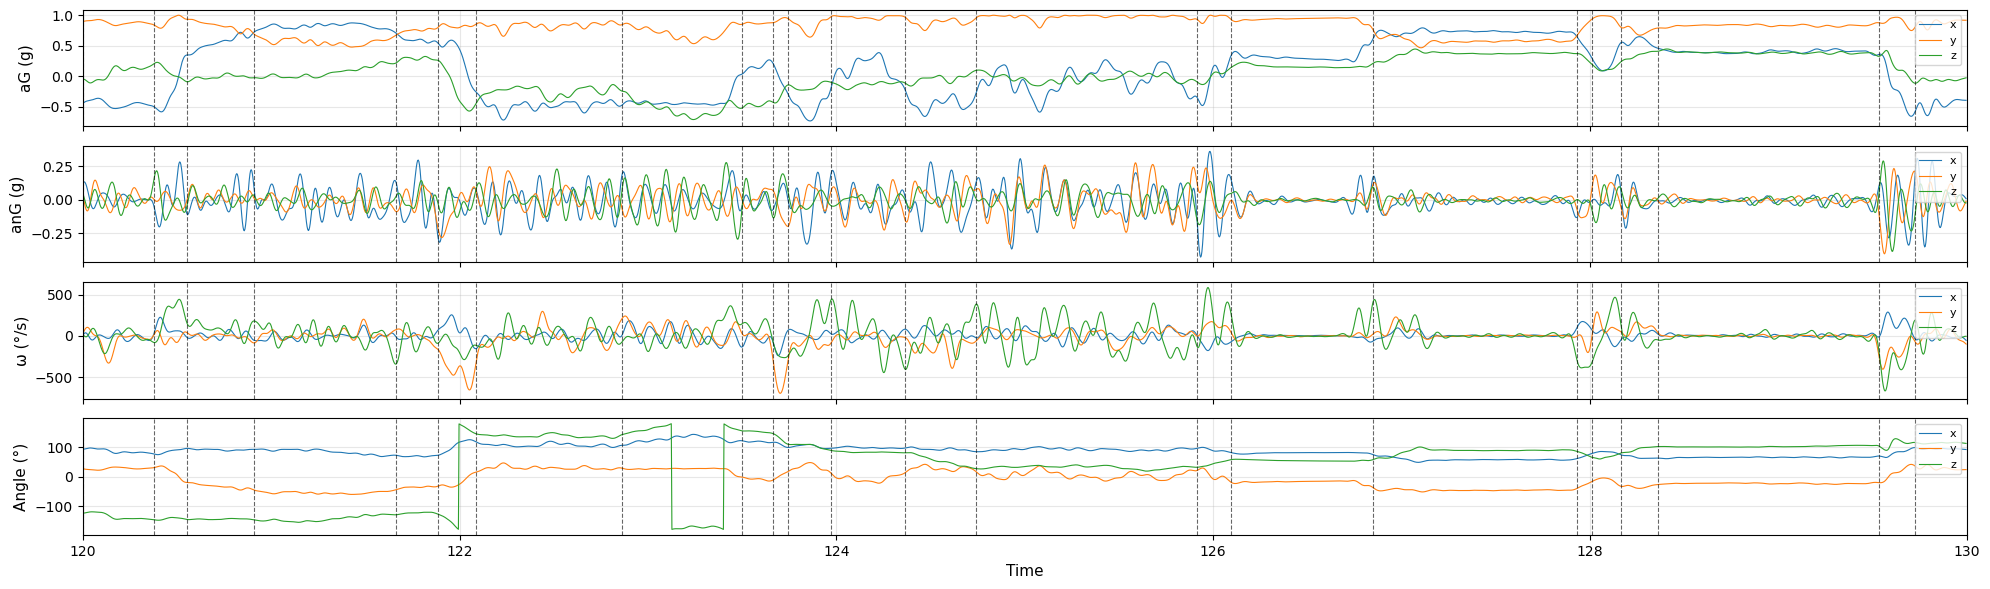

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import ruptures as rpt

# ------------------------------------------------------------
# 辅助函数（已适配 13 列输入，第 0 列为时间戳）
# ------------------------------------------------------------

def compute_gamma(seg):
    """从 (n, 13) 片段计算 gamma，使用 1-3 和 7-10 列。"""
    sig = np.concatenate([seg[:, 1:4], seg[:, 7:10]], axis=1)
    z = (sig - sig.mean(axis=0)) / (sig.std(axis=0) + 1e-12)
    tv = np.sum(z.var(axis=0))
    return 1.0 / tv if tv > 0 else 1.0


def dissect_imu_single(data, gamma, penalty, sr=300, min_size=10):
    """
    单段 CPD。输入 (n, 13)，第 0 列为时间戳。
    返回 list of (m, 13)，保留时间戳。
    """
    n = len(data)
    if n < 2 * min_size:
        return [data]

    sig = np.concatenate([data[:, 1:4], data[:, 7:10]], axis=1)
    z = (sig - sig.mean(axis=0)) / (sig.std(axis=0) + 1e-12)

    algo = rpt.KernelCPD(kernel="rbf", params={"gamma": gamma}, min_size=min_size)
    algo.fit(z)
    bkps = algo.predict(pen=penalty)

    segs, start = [], 0
    for end in bkps:
        if end - start >= min_size:
            segs.append(data[start:end])
        start = end
    return segs


# ------------------------------------------------------------
# 可视化（输入为已分割的 13 列数据列表）
# ------------------------------------------------------------

def plot_imu_segments(segments, t_start=None, t_end=None, figsize=(16, 10)):
    """
    绘制分段 IMU 数据。

    Parameters
    ----------
    segments : list of np.ndarray
        每段 (m, 13)，第 0 列为时间戳，后 12 列依次为
        [aGx,aGy,aGz, anGx,anGy,anGz, wx,wy,wz, roll,pitch,yaw]。
    """
    # 拼接
    full = np.vstack(segments)
    t = full[:, 0]
    data = full[:, 1:]

    # 截断
    t_start = t_start if t_start is not None else t[0]
    t_end = t_end if t_end is not None else t[-1]
    mask = (t >= t_start) & (t <= t_end)
    t, data = t[mask], data[mask]

    # 片段边界
    bounds = [seg[0, 0] for seg in segments
              if seg[0, 0] <= t_end and seg[-1, 0] >= t_start]

    # 4 组 3 通道
    groups = [
        (data[:, 0:3], 'aG (g)'),
        (data[:, 3:6], 'anG (g)'),
        (data[:, 6:9], 'ω (°/s)'),
        (data[:, 9:12], 'Angle (°)'),
    ]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    names = ['x', 'y', 'z']

    fig, axes = plt.subplots(4, 1, figsize=figsize, sharex=True)
    for ax, (d, title) in zip(axes, groups):
        for ch in range(3):
            ax.plot(t, d[:, ch], color=colors[ch], lw=0.8, label=names[ch])
        for b in bounds:
            ax.axvline(b, color='black', linestyle='--', lw=0.8, alpha=0.6)
        ax.set_ylabel(title, fontsize=11)
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(t_start, t_end)

    axes[-1].set_xlabel('Time', fontsize=11)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 使用示例
# ------------------------------------------------------------
plot_imu_segments(data1_CPDsegments, t_start=120, t_end=130, figsize=(20, 6))




# sr = 300

# for p in [2.5, 7.5, 15.0, 30]:
#     CPD_test = []
#     for seg in seg_data:          # seg_data: list of (n, 13)
#         gamma = compute_gamma(seg)
#         segs = dissect_imu_single(seg, gamma=gamma, penalty=p, sr=sr, min_size=10)
#         CPD_test.extend(segs)
#         print(f"Segment: {len(segs)} sub-segs, gamma={gamma:.4f}")

#     plot_imu_segments(CPD_test, t_start=120, t_end=130, figsize=(20, 6))

In [ ]:
print(data1_CPDsegments[0].shape)

In [17]:
#原版特征提取
import sys
from pathlib import Path

# 指向 dissect 的父文件夹（即包含 dissect 文件夹的那一层）
dissect_parent = Path("F:/IMU_computational_ethology/rfayat-DISSeCT-0503c3f")
sys.path.insert(0, str(dissect_parent))

import pandas as pd
import numpy as np
import scipy.stats
from scipy.spatial.transform import Rotation as R
from dissect.data_loading import COL_ACC_G, COL_GYR, COL_QUAT, COL_ACC_R, SR
from dissect.angles import get_angle, get_azimuth_estimate
from sklearn.linear_model import LinearRegression, HuberRegressor
from dissect.utils import reshape_input_2D, handle_col_names, split_and_map


def gradient_df(df):
    "Return the gradient of each column of a dataframe, preserving the DataFrame."
    grad = np.gradient(df.values, axis=0)
    col_new = [f"{c}_gradient" for c in df.columns]
    return pd.DataFrame(grad, columns=col_new, index=df.index)


def tilt_from_euclidean(X, degrees=True):
    """Return roll and pitch from the euclidean coordinates of X.

    Not the usual definition of these angles, roll angle is here the smallest
    angle to the xz plane (in -90, 90) while pitch is between -180 and 180.

    North pole corresponds to 0 for both.

    Parameters
    ----------
    X : array, shape = (n_points, 3)
        The euclidean coordinates on S2
    degrees : bool (default: True)
        Set `degrees`to True to obtain values in degrees, False for radians.

    """
    theta1 = np.arctan2(X[:, 1], X[:, 2])
    theta2 = np.arctan2(X[:, 1], -X[:, 2])
    select_theta1 = np.abs(theta1) < np.abs(theta2)
    roll = np.where(select_theta1, theta1, theta2)
    pitch = np.arctan2(X[:, 0], X[:, 2])

    if degrees:
        return np.degrees(np.c_[roll, pitch])
    else:
        return np.c_[roll, pitch]


def _fit_vMF(X, weights=None):
    "Fit a von Mises Fisher on 3D input data and return the MLE parameters"
    n_dim = 3
    X = X / np.linalg.norm(X, axis=1, keepdims=True)
    X_av = np.average(X, axis=0, weights=weights)
    # Simple approximation (Sra, 2011)
    R = np.linalg.norm(X_av)
    kappa_est = R * (n_dim - R**2) / (1 - R**2)

    return X_av / R, kappa_est


def extract_vmf_features(X, prepend=""):
    "Features extracted by fitting a vMF distribution on X."
    mu, kappa = _fit_vMF(X)
    dispersion = np.sqrt(1 / kappa)
    features_names = ["dispersion", "mux", "muy", "muz"]
    features = [dispersion, *mu.squeeze()]
    return {f"{prepend}{k}": f for k, f in zip(features_names, features)}


@reshape_input_2D
@handle_col_names
def compute_corr(X, columns=None):
    "Return a dictionary of the correlations of the different axes."
    corr_all = {}
    corrcoef = np.corrcoef(X, rowvar=False)
    for i, c1 in enumerate(columns):
        for j, c2 in enumerate(columns):
            if i > j:  # Lower diagonal of the correlation matrix
                corr_all[f"corr_{c1}_{c2}"] = corrcoef[i, j]
    return corr_all


@reshape_input_2D
@handle_col_names
def compute_autoregressive_coef(X, columns=None, fit_intercept=True, robust=False, **kwargs):
    """Coefficients for an AR model with lag 1.
    
    Returns the coefficient (elements of A) of a linear model with form:
        X_{t+1} = X_{t} + A.X_{t}
        
    DO NOT USE as features directly, useful for the singular values of the matrix ? 
    """
    if robust:  # We need one regressor per dimension (only 1-D regression is supported)
        # N.B. Maybe not a good idea because we fit different intercepts
        coef = []
        for i, x in enumerate(X.T):
            lr = HuberRegressor(fit_intercept=fit_intercept,
                                **kwargs).fit(X[:-1], x[1:])
            coef.append(lr.coef_)
        coef = np.vstack(coef).T

    else:
        lr = LinearRegression(fit_intercept=fit_intercept).fit(X[:-1], X[1:])
        coef = lr.coef_
    ar_coef = {}
    for i, c1 in enumerate(columns):
        for j, c2 in enumerate(columns):
            ar_coef[f"AR_{c1}_{c2}"] = coef[i, j]
    return ar_coef


@reshape_input_2D
@handle_col_names
def compute_basic_features(X, columns=None, compute_quartiles=True, compute_higher_moments=True):
    "Basic 1D features for each axis of a multi-dimensional time series."
    mu = {f"{c}_mean": m for c, m in zip(columns, X.mean(axis=0))}
    sigma = {f"{c}_std": m for c, m in zip(columns, X.std(axis=0))}
    min_all = {f"{c}_min": m for c, m in zip(columns, X.min(axis=0))}
    max_all = {f"{c}_max": m for c, m in zip(columns, X.max(axis=0))}

    quartiles = {}
    if compute_quartiles:
        # quartiles of each column
        quartiles_all = np.percentile(X, [25., 50., 75.], axis=0)
        for p_all, name in zip(quartiles_all, ["p25", "median", "p75"]):
            for p, c in zip(p_all, columns):
                quartiles[f"{c}_{name}"] = p

    higher_moments = {}
    if compute_higher_moments:
        skew_all = scipy.stats.skew(X, axis=0)
        kurt_all = scipy.stats.kurtosis(X, axis=0)
        for c, skew, kurt in zip(columns, skew_all, kurt_all):
            higher_moments[f"{c}_skew"] = skew
            higher_moments[f"{c}_kurt"] = kurt

    return {**mu, **sigma, **min_all, **max_all, **quartiles, **higher_moments}


def number_crossing_m(x, m=0.):
    "Number of crossing of value m by the 1D array x."
    is_crossing_up = (x[:-1] <= m) & (x[1:] > m)
    is_crossing_down = (x[:-1] > m) & (x[1:] < m)
    return is_crossing_up.sum() + is_crossing_down.sum()


@reshape_input_2D
@handle_col_names
def compute_ts_features(X, columns=None):
    "Basic time-series 1D features for each axis of a multi-dimensional time series."
    ts_features = {}
    for x, c in zip(X.T, columns):
        ts_features[f"{c}_zerocrossing"] = number_crossing_m(x, 0.)
    return ts_features


def compute_tilt_features(X, sr=SR):
    "Features derived from tilt (accG)."
    duration = len(X) / sr
    # von Mises-Fisher features for tilt
    vmf_attitude = extract_vmf_features(X, prepend="attitude_")

    # Tilt change between the 1st and last sample
    tilt_change_angle = get_angle(X[0], X[-1])
    tilt_change_speed = tilt_change_angle / duration

    return {
        **vmf_attitude,
        "tilt_change_x": X[-1, 0] - X[0, 0],
        "tilt_change_y": X[-1, 1] - X[0, 1],
        "tilt_change_z": X[-1, 2] - X[0, 2],
        "tilt_change_angle": tilt_change_angle,
        "tilt_change_speed": tilt_change_speed,
        "tilt_start_x": X[0, 0],
        "tilt_start_y": X[0, 1],
        "tilt_start_z": X[0, 2],
        "tilt_end_x": X[-1, 0],
        "tilt_end_y": X[-1, 1],
        "tilt_end_z": X[-1, 2]
    }


def compute_azimuth_features(X, sr=SR):
    "Features derived from 3D azimuth."
    duration = len(X) / sr
    # von Mises-Fisher features for the 3D azimuth
    vmf_azimuth = extract_vmf_features(X, prepend="azimuth_")

    # Angle between the first and last sample
    azimuth3d_angle = get_angle(X[0], X[-1])
    azimuth3d_speed = azimuth3d_angle / duration

    return {
        **vmf_azimuth,
        "azimuth3d_angle": azimuth3d_angle,
        "azimuth3d_speed": azimuth3d_speed,

    }


def compute_gyr_earth_features(X, sr=SR):
    "Features derived from gyroscope data in an earth reference frame."
    duration = len(X) / sr
    azimuth2d_cumulative_change = X[:, 2].sum() / sr
    azimuth2d_cumulative_speed = azimuth2d_cumulative_change / duration
    return {"azimuth2d_cumulative_change": azimuth2d_cumulative_change,
            "azimuth2d_cumulative_speed": azimuth2d_cumulative_speed,
            **compute_basic_features(np.cumsum(X[:, 2] / sr),
                                     columns=["azimuth2d_change"],
                                     compute_quartiles=True,
                                     compute_higher_moments=False)}


def compute_imu_features_basic(imu, sr=SR, col_acc_G=COL_ACC_G,
                               col_gyr=COL_GYR, col_acc_R=COL_ACC_R):
    "Compute all basic imu features."
    duration = len(imu) / sr
    basic_features = compute_basic_features(imu[col_gyr + col_acc_G + col_acc_R],
                                            compute_quartiles=True,
                                            compute_higher_moments=False)

    # basic features on the diff
    imu_grad = gradient_df(imu[col_gyr + col_acc_G + col_acc_R])
    basic_features_grad = compute_basic_features(imu_grad,
                                                 compute_quartiles=True,
                                                 compute_higher_moments=False)

    # basic features on the norm of the gyroscope and accR
    gyr_norm = np.linalg.norm(imu[col_gyr].values, axis=1)
    acc_R_norm = np.linalg.norm(imu[col_acc_R].values, axis=1)
    df_norm = pd.DataFrame(np.c_[gyr_norm, acc_R_norm], columns=[
                           "gyr_norm", "acc_R_norm"])
    basic_features_norm = compute_basic_features(df_norm,
                                                 compute_quartiles=True,
                                                 compute_higher_moments=False)

    # ts features on the gyroscope, acc_G and acc_R and the gyr and accR gradients
    ts_features = compute_ts_features(imu[col_gyr + col_acc_R + col_acc_G])
    # Correlation coefficients
    corr_all = compute_corr(imu[COL_ACC_R + COL_GYR])

    return {
        "duration": duration,
        "duration_log10": np.log10(duration),
        **basic_features,
        **basic_features_grad,
        **basic_features_norm,
        **ts_features,
        **corr_all,
        "gyr_energy": np.sum(gyr_norm),
        "acc_R_energy": np.sum(acc_R_norm)
    }


def compute_imu_features_attitude(imu, sr=SR, col_acc_G=COL_ACC_G,
                                  col_gyr=COL_GYR, col_quat=COL_QUAT):
    "Compute all imu features derived from AHRS filters."
    # Azimuth estimate using computed quaternions
    azimuth3d = get_azimuth_estimate(imu[col_quat].values,
                                     first_sample_azimuth_zero=True)
    # Change of referential using computed quaternions
    gyr_earth = R.from_quat(imu[col_quat].values).apply(imu[col_gyr].values)

    return {
        **compute_tilt_features(imu[col_acc_G].values, sr=sr),
        **compute_azimuth_features(azimuth3d, sr=sr),
        **compute_gyr_earth_features(gyr_earth, sr=sr)
    }


def compute_feature_all(imu, chpt, **kwargs):
    "Compute all features on windows of inertial data."
    X_basic = split_and_map(
        imu,
        chpt[:-1],
        lambda x: compute_imu_features_basic(x, **kwargs),
        n_jobs=None
    )
    X_basic = pd.DataFrame(X_basic)

    X_attitude = split_and_map(imu,
                               chpt[:-1],
                               lambda x: compute_imu_features_attitude(x, **kwargs)
    )
    X_attitude = pd.DataFrame(X_attitude)

    return X_basic.join(X_attitude)


# ==================== 新增主函数 ====================

def extract_imu_features(data, sr):
    """
    将9列IMU时序数据打包提取为240维特征向量。

    输入数据列顺序（9列）：
        COL_GYR (3列): 陀螺仪 x, y, z
        COL_ACC_G (3列): 重力方向加速度 x, y, z
        COL_ACC_R (3列): 参考系加速度 x, y, z

    Parameters
    ----------
    data : np.ndarray, shape (n_samples, 9)
        9列时序数据，列顺序须与 COL_GYR + COL_ACC_G + COL_ACC_R 一致
    sr : float
        采样频率 (Hz)

    Returns
    -------
    features : np.ndarray, shape (240,)
        240维特征向量（实际有效特征约198维，不足部分补零）
    """
    # 1) 构造 DataFrame（使用原始代码中已导入的列名常量）
    columns = COL_GYR + COL_ACC_G + COL_ACC_R
    imu = pd.DataFrame(data, columns=columns)

    # 2) 从 acc_G 与 gyr 在线估算四元数，补全 COL_QUAT
    acc_G_vals = imu[COL_ACC_G].values
    gyr_vals = imu[COL_GYR].values
    n = len(acc_G_vals)
    dt = 1.0 / sr

    # 初始姿态：从第一帧加速度计算 roll/pitch，yaw=0
    acc0 = acc_G_vals[0]
    roll0 = np.arctan2(acc0[1], acc0[2])
    pitch0 = np.arctan2(-acc0[0], np.sqrt(acc0[1]**2 + acc0[2]**2))
    yaw0 = 0.0
    r = R.from_euler('xyz', [roll0, pitch0, yaw0])
    quats = np.zeros((n, 4))
    quats[0] = r.as_quat()          # scipy 格式 [x, y, z, w]

    # 后续帧：用陀螺仪积分更新四元数（简化互补滤波）
    for i in range(1, n):
        gyr_prev = gyr_vals[i - 1]
        angle = np.linalg.norm(gyr_prev) * dt
        if angle > 1e-6:
            axis = gyr_prev / np.linalg.norm(gyr_prev)
            delta_r = R.from_rotvec(axis * angle)
            r_prev = R.from_quat(quats[i - 1])
            r_curr = r_prev * delta_r
            quats[i] = r_curr.as_quat()
        else:
            quats[i] = quats[i - 1]

    # 将四元数加入 DataFrame
    for i, col in enumerate(COL_QUAT):
        imu[col] = quats[:, i]

    # 3) 调用原始特征提取函数（不修改原始逻辑）
    features_basic = compute_imu_features_basic(
        imu, sr=sr, col_acc_G=COL_ACC_G, col_gyr=COL_GYR, col_acc_R=COL_ACC_R
    )
    features_attitude = compute_imu_features_attitude(
         imu, sr=sr, col_acc_G=COL_ACC_G, col_gyr=COL_GYR, col_quat=COL_QUAT
    )

    # 4) 合并并固定输出240维
    features_dict = {**features_basic, **features_attitude}
    #features_dict = {**features_basic}
    feature_vec = np.array(list(features_dict.values()), dtype=np.float32)

    target_dim = 240
    n_features = len(feature_vec)
    if n_features < target_dim:
        feature_vec = np.pad(feature_vec, (0, target_dim - n_features), mode='constant')
    elif n_features > target_dim:
        feature_vec = feature_vec[:target_dim]

    return feature_vec

Could not find module ahrs_cython.
Falling back on the pure Python implementation of the ahrs module (much slower).
For computational efficiency you can follow the instructions at:
https://github.com/rfayat/AHRS_cython



In [ ]:
#提取240维特征
import numpy as np
from numpy.linalg import norm

def extract_features(seg_data, fs=100):
    channels = []
    feats = []
    aG = seg_data[:, 0:3].astype(float)
    anG = seg_data[:,3:6].astype(float)
    w = seg_data[:, 6:9].astype(float)
    angles = seg_data[:, 9:12].astype(float)
    
    for ch in range(9):
        x = seg_data[:, ch]
        channels +=  [x]
    
    for ch in range(9):
        x = seg_data[:, ch]
        gradx = np.gradient(x, 1/fs)
        channels += [gradx]
    
    norm_w = np.linalg.norm(seg_data[:, 6:9], axis=1)
    norm_ang = np.linalg.norm(seg_data[:, 3:6], axis=1)
    channels += [norm_w, norm_ang]
    #构建20类数据
    
    for ch in channels:
        mean = np.mean(ch)
        std = np.std(ch)
        max = np.max(ch)
        min = np.min(ch)
        median = np.median(ch)
        q25 = np.percentile(ch, 25)
        q75 = np.percentile(ch, 75)             
        feats += [mean, std, min, max, median, q25, q75]
    #提取20维数据的7个特征，共140个特征

    duration = seg_data.shape[0]/ fs
    log_duration = np.log10(duration)
    feats += [duration, log_duration]
    #每段时长与对数时长，2维

    corr = np.corrcoef(seg_data[:, 3:9].T)[np.triu_indices(6, k=1)]
    feats += corr.tolist()
    #Ω和AnG的两两相关性，15维

    energy_w = np.sum(np.square(seg_data[:, 6:9]))
    energy_anG = np.sum(np.square(seg_data[:, 3:6]))
    feats += [energy_w, energy_anG]
    #AnG和w的信号能量，2维 

    for ch in range(9):
        x = seg_data[:, ch]
        zeropass = np.sum((x[:-1] * x[1:]) < 0)
        feats += [zeropass]
    #所有通道的过零次数，9维

    
    r = np.radians(angles)
    cr = np.cos(r[:, 0]);  sr_roll = np.sin(r[:, 0])   # roll
    cp = np.cos(r[:, 1]);  sp = np.sin(r[:, 1])       # pitch
    cy = np.cos(r[:, 2]);  sy = np.sin(r[:, 2])       # yaw

    # 3. 构建旋转矩阵 R (head -> Earth, ZYX 内旋)
    R = np.zeros((len(seg_data), 3, 3))
    R[:, 0, 0] = cy * cp
    R[:, 0, 1] = cy * sp * sr_roll - sy * cr
    R[:, 0, 2] = cy * sp * cr + sy * sr_roll
    R[:, 1, 0] = sy * cp
    R[:, 1, 1] = sy * sp * sr_roll + cy * cr
    R[:, 1, 2] = sy * sp * cr - cy * sr_roll
    R[:, 2, 0] = -sp
    R[:, 2, 1] = cp * sr_roll
    R[:, 2, 2] = cp * cr

    w_E = np.einsum('nij,nj->ni', R, w)
    w_Ez = w_E[:, 2]



    cum_az = np.cumsum(w_Ez)/100
    mean = np.mean(cum_az)
    std = np.std(cum_az)
    min = np.min(cum_az)
    max = np.max(cum_az)
    median = np.median(cum_az)
    q25 = np.percentile(cum_az, 25)
    q75 = np.percentile(cum_az, 75) 
    net_az = np.sum(w_Ez) /100
    net_az_speed = np.sum(w_Ez) / (len(w_Ez) / fs)   # 或 np.sum(w_Ez) / duration
    feats += [mean, std, min, max, median, q25, q75, net_az, net_az_speed] 
    #重力极化参考系陀螺仪方位特征，13维


    aG = seg_data[:, 0:3].astype(float)
    angles = seg_data[:, 9:12].astype(float)

    # 初始/最终重力向量坐标
    aG_first = aG[0, :]
    aG_last = aG[-1, :]

    # 重力向量坐标变化
    aG_delta = aG_last - aG_first
    # 头部倾斜总变化 (度)
    tilt_change = np.arccos(np.clip(np.dot(aG_first, aG_last), -1.0, 1.0))
    # 头部倾斜净变化速度
    tilt_change_speed = tilt_change / duration

    # 3D 航向：旋转矩阵 R (head->Earth) 的第一列，即 R @ [1,0,0]
    r = np.radians(angles)
    cr = np.cos(r[:, 0]); sr_roll = np.sin(r[:, 0])
    cp = np.cos(r[:, 1]); sp = np.sin(r[:, 1])
    cy = np.cos(r[:, 2]); sy = np.sin(r[:, 2])

    R = np.zeros((len(seg_data), 3, 3))
    R[:, 0, 0] = cy * cp
    R[:, 0, 1] = cy * sp * sr_roll - sy * cr
    R[:, 0, 2] = cy * sp * cr + sy * sr_roll
    R[:, 1, 0] = sy * cp
    R[:, 1, 1] = sy * sp * sr_roll + cy * cr
    R[:, 1, 2] = sy * sp * cr - cy * sr_roll
    R[:, 2, 0] = -sp
    R[:, 2, 1] = cp * sr_roll
    R[:, 2, 2] = cp * cr

    heading = R[:, :, 0]          # 每行是一个 3D heading 向量
    heading_first = heading[0, :]
    heading_last = heading[-1, :]
    # 3D 航向总变化
    heading_change = np.arccos(np.clip(np.dot(heading_first, heading_last), -1.0, 1.0))
    # 3D 航向净变化速度
    heading_change_speed = heading_change / duration
    feats += [aG_first[0], aG_first[1], aG_first[2], aG_last[0], aG_last[1], aG_last[2], aG_delta[0], aG_delta[1], aG_delta[2], tilt_change, tilt_change_speed, heading_change, heading_change_speed]
    #头部倾斜与 3D 航向特征，13维

        # ========== vMF 均值方向与离散度 (8维) ==========
    aG = seg_data[:, 0:3].astype(float)

    # head tilt 单位向量
    aG_norm = aG / (np.linalg.norm(aG, axis=1, keepdims=True) + 1e-12)

    # 3D heading 已在上一步计算: heading = R[:, :, 0]

    def vmf_mean_disp(vectors):
        mean_vec = np.mean(vectors, axis=0)
        R_bar = np.linalg.norm(mean_vec)
        mu = mean_vec / (R_bar + 1e-12)
        if R_bar > 0.999:
            kappa = 1e6
        else:
            kappa = R_bar * (3.0 - R_bar**2) / (1.0 - R_bar**2 + 1e-12)
        dispersion = 1.0 / np.sqrt(kappa + 1e-12)
        return mu, dispersion

    mu_tilt, disp_tilt = vmf_mean_disp(aG_norm)
    mu_head, disp_head = vmf_mean_disp(heading)

    feats += [
        mu_tilt[0], mu_tilt[1], mu_tilt[2], disp_tilt,
        mu_head[0], mu_head[1], mu_head[2], disp_head
    ]
    # ========== CWT 时频特征 (42维) ==========
    sr = 100.0

    signals = [
        seg_data[:, 3], seg_data[:, 4], seg_data[:, 5],
        seg_data[:, 6], seg_data[:, 7], seg_data[:, 8]
    ]

    freqs = np.logspace(0, np.log10(20), 20)
    band_edges = np.linspace(2.5, 20, 8)
    freq_band = np.digitize(freqs, band_edges) - 1
    freq_band = np.clip(freq_band, 0, 6)

    n_cycles = 5
    feats_cwt = []

    for sig in signals:
        n = len(sig)
        t_offset = (np.arange(n) - n // 2) / sr
        
        coeff_mags = np.zeros((20, n))
        for i, f in enumerate(freqs):
            sigma_t = n_cycles / (2.0 * np.pi * f)
            wavelet = np.exp(2j * np.pi * f * t_offset) * np.exp(-t_offset**2 / (2.0 * sigma_t**2))
            wavelet = wavelet / (np.sum(np.abs(wavelet)) + 1e-12)
            conv = np.convolve(sig, wavelet, mode='same')
            coeff_mags[i, :] = np.abs(conv)
        
        for b in range(7):
            mask = freq_band == b
            if np.any(mask):
                band_mean = np.mean(coeff_mags[mask, :], axis=0)
                med = np.median(band_mean)
            else:
                med = 0.0
            feats_cwt.append(np.log10(med + 1e-12))

    feats += feats_cwt

    return feats


In [ ]:
features =  []
for s in data1_CPDsegments:
    feat = extract_imu_features(s[:,0:9], 300)
    features.append(feat)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture


def find_elbow_kneedle(errors, ks, sensitivity=1.0):
    """
    Kneedle 算法：找曲线从陡峭到平缓的"膝盖"点。
    原理：将曲线归一化到单位正方形，找距对角线（y=x）垂直距离最大的点。
    """
    # 归一化到 [0,1]×[0,1]
    x_norm = (ks - ks.min()) / (ks.max() - ks.min())
    y_norm = (errors - errors.min()) / (errors.max() - errors.min())
    
    # 对角线 y = x，计算每个点到对角线的垂直距离（y=x 的上方为正）
    # 距离公式：|y - x| / sqrt(2)，这里直接用 (y - x) 因为曲线在对角线上方
    distances = y_norm - x_norm
    
    # 找距离最大的点（考虑 sensitivity，允许在平台期后忽略微小波动）
    # 使用差分平滑，避免噪声导致的伪拐点
    diff = np.diff(distances)
    # 只考虑距离仍在增长的区域，增长停止后的点视为已进入平台
    growth_mask = np.concatenate([[True], diff > -0.01 * sensitivity])
    
    valid_distances = distances.copy()
    valid_distances[~growth_mask] = -np.inf
    
    knee_idx = np.argmax(valid_distances)
    return ks[knee_idx]


def find_elbow_curvature(errors, ks):
    """
    离散曲率法：找二阶差分变化最大的点（曲率极值）。
    等价于找"一阶导数下降最快"的位置。
    """
    # 一阶差分（离散导数）
    d1 = np.diff(errors)
    # 二阶差分（导数的变化）
    d2 = np.diff(d1)
    
    # 曲率近似 ∝ |d2| / (1 + d1^2)^(3/2)
    # 由于 d1 为负（误差递减），取绝对值
    d1_mid = 0.5 * (d1[:-1] + d1[1:])  # 对齐长度
    curvature = np.abs(d2) / (1 + d1_mid**2)**1.5
    
    # 忽略边界效应（前3个和后3个点）
    safe_curvature = curvature.copy()
    safe_curvature[:3] = 0
    safe_curvature[-3:] = 0
    
    elbow_idx = np.argmax(safe_curvature) + 1  # +1 因为 diff 缩短
    return ks[elbow_idx]


def find_elbow_variance(cumvar, thresholds=[0.85, 0.90, 0.95]):
    """
    累积解释方差阈值法：找达到指定方差比例的最小 k。
    """
    results = {}
    for thr in thresholds:
        idx = np.argmax(cumvar >= thr)
        results[f"{int(thr*100)}%"] = idx + 1
    return results


def find_elbow_silhouette(X_pca_dict, ks, n_gmm=8, subsample=5000, random_state=42):
    """
    轮廓系数法：对每个 k，用 GMM 聚类后计算轮廓系数，找最大值。
    计算量大，默认子采样。
    """
    rng = np.random.RandomState(random_state)
    best_sil = -1
    best_k = ks[0]
    
    silhouette_scores = []
    
    for k in ks:
        Xk = X_pca_dict[k]
        if Xk.shape[1] > k:  # 安全检查
            continue
            
        # 子采样加速
        if len(Xk) > subsample:
            idx = rng.choice(len(Xk), subsample, replace=False)
            Xsub = Xk[idx]
        else:
            Xsub = Xk
        
        gmm = GaussianMixture(n_components=min(n_gmm, len(Xsub)//10),
                              covariance_type='diag',
                              random_state=random_state,
                              n_init=2)
        labels = gmm.fit_predict(Xsub)
        
        # 如果 GMM 只产生1个类，跳过
        if len(np.unique(labels)) < 2:
            silhouette_scores.append(np.nan)
            continue
            
        sil = silhouette_score(Xsub, labels)
        silhouette_scores.append(sil)
        
        if sil > best_sil:
            best_sil = sil
            best_k = k
    
    return best_k, silhouette_scores


def select_optimal_pca_components(X, 
                                  max_k=80,
                                  fs=100,
                                  use_silhouette=False,
                                  random_state=42,
                                  plot=True):
    """
    综合多策略选择最优 PCA 维度。
    
    返回:
        best_k : int
            综合推荐值（多种方法的共识或中位数）
        diagnostics : dict
            包含所有中间结果和可视化
    """
    # 1. 标准化
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    n_samples, n_features = Xs.shape
    max_k = min(max_k, n_samples, n_features)
    
    # 2. 计算 PCA 全谱
    pca_full = PCA(n_components=max_k, random_state=random_state)
    pca_full.fit(Xs)
    cumvar = np.cumsum(pca_full.explained_variance_ratio_)
    
    # 3. 计算各 k 的重构误差（用训练集自身重构，无 CV，仅用于肘部法）
    # 注意：这里用训练集重构误差是为了速度；若数据量大，可用子采样
    ks = np.arange(1, max_k + 1)
    errors = []
    for k in ks:
        pca = PCA(n_components=k, random_state=random_state)
        Xk = pca.fit_transform(Xs)
        X_recon = pca.inverse_transform(Xk)
        mse = np.mean((Xs - X_recon)**2)
        errors.append(mse)
    errors = np.array(errors)
    
    # 4. 各种方法
    # 4.1 Kneedle
    k_kneedle = find_elbow_kneedle(errors, ks, sensitivity=1.0)
    
    # 4.2 曲率法
    k_curvature = find_elbow_curvature(errors, ks)
    
    # 4.3 方差阈值
    var_results = find_elbow_variance(cumvar)
    
    # 4.4 轮廓系数（可选，慢）
    sil_scores = None
    k_silhouette = None
    if use_silhouette:
        X_pca_dict = {k: PCA(n_components=k, random_state=random_state).fit_transform(Xs) 
                      for k in ks[::3]}  # 每3个采样一次加速
        k_silhouette, sil_scores = find_elbow_silhouette(
            X_pca_dict, ks[::3], random_state=random_state
        )
    
    # 5. 综合推荐：取各方法的中位数（鲁棒共识）
    candidates = [k_kneedle, k_curvature, var_results['90%']]
    if k_silhouette is not None:
        candidates.append(k_silhouette)
    
    best_k = int(np.median(candidates))
    
    # 6. 可视化
    if plot:
        n_plots = 4 if use_silhouette else 3
        fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 4))
        
        # 图1: 重构误差 + 拐点
        ax = axes[0]
        ax.plot(ks, errors, 'o-', color='steelblue', markersize=3, label='Reconstruction Error')
        ax.axvline(k_kneedle, color='crimson', linestyle='--', label=f'Kneedle k={k_kneedle}')
        ax.axvline(k_curvature, color='orange', linestyle='--', label=f'Curvature k={k_curvature}')
        ax.axvline(best_k, color='black', linestyle='-', alpha=0.5, label=f'Consensus k={best_k}')
        ax.set_xlabel('Number of PCs (k)')
        ax.set_ylabel('MSE Reconstruction Error')
        ax.set_title('Elbow Detection (Kneedle & Curvature)')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        
        # 图2: 累积解释方差
        ax = axes[1]
        ax.plot(ks, cumvar, 'o-', color='seagreen', markersize=3)
        for thr_label, thr_k in var_results.items():
            ax.axvline(thr_k, linestyle='--', alpha=0.7, label=f'{thr_label}: k={thr_k}')
        ax.axhline(0.90, color='gray', linestyle=':', alpha=0.5)
        ax.set_xlabel('Number of PCs (k)')
        ax.set_ylabel('Cumulative Explained Variance')
        ax.set_title('Variance Thresholds')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        
        # 图3: 一阶/二阶差分（曲率诊断）
        ax = axes[2]
        d1 = np.diff(errors)
        d2 = np.diff(d1)
        ax.plot(ks[1:], d1, '-', color='coral', label='1st diff (slope)')
        ax2 = ax.twinx()
        ax2.plot(ks[2:], np.abs(d2), '-', color='purple', alpha=0.7, label='|2nd diff|')
        ax.axvline(k_curvature, color='orange', linestyle='--', label=f'Curvature k={k_curvature}')
        ax.set_xlabel('Number of PCs (k)')
        ax.set_ylabel('1st Difference', color='coral')
        ax2.set_ylabel('|2nd Difference|', color='purple')
        ax.set_title('Difference Diagnostics')
        ax.grid(True, alpha=0.3)
        
        # 图4: 轮廓系数（若启用）
        if use_silhouette and sil_scores is not None:
            ax = axes[3]
            ax.plot(ks[::3], sil_scores, 'o-', color='teal', markersize=4)
            ax.axvline(k_silhouette, color='teal', linestyle='--', label=f'Silhouette k={k_silhouette}')
            ax.set_xlabel('Number of PCs (k)')
            ax.set_ylabel('Silhouette Score')
            ax.set_title('GMM Silhouette (Downstream)')
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    diagnostics = {
        'k_kneedle': k_kneedle,
        'k_curvature': k_curvature,
        'k_variance_85': var_results['85%'],
        'k_variance_90': var_results['90%'],
        'k_variance_95': var_results['95%'],
        'k_silhouette': k_silhouette,
        'k_consensus': best_k,
        'cumvar': cumvar,
        'errors': errors,
        'ks': ks
    }
    
    print(f"{'='*50}")
    print(f"PCA Component Selection Diagnostics")
    print(f"{'='*50}")
    print(f"Kneedle elbow:        k = {k_kneedle}")
    print(f"Curvature peak:       k = {k_curvature}")
    print(f"Variance 85%:         k = {var_results['85%']}")
    print(f"Variance 90%:         k = {var_results['90%']}")
    print(f"Variance 95%:         k = {var_results['95%']}")
    if k_silhouette:
        print(f"GMM Silhouette:       k = {k_silhouette}")
    print(f"{'-'*50}")
    print(f"Consensus (median):   k = {best_k}")
    print(f"{'='*50}")
    
    return best_k, diagnostics

X = np.array(features)  # 假设 features 是一个包含所有特征向量的列表
# ==================== 使用示例 ====================
if __name__ == "__main__":
   
    # 运行综合诊断
    best_k, diag = select_optimal_pca_components(
        X,
        max_k=60,           # 搜索到 60 维即可
        use_silhouette=False,  # 设为 True 会慢很多
        random_state=42
    )
    
    # 最终拟合
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    pca_final = PCA(n_components=best_k, random_state=42)
    X_pca = pca_final.fit_transform(Xs)
    
    print(f"\nFinal PCA: {X.shape[1]}D -> {best_k}D")
    print(f"Explained variance: {np.sum(pca_final.explained_variance_ratio_):.2%}")

In [19]:
#降维
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def dim_reduction(features, PCs=30):
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    pca = PCA(n_components=PCs)
    features_pca = pca.fit_transform(features_scaled)
    
    # 分析前 5 个 PC 的主要高贡献特征
    n_top = min(5, PCs)
    top_features = {}
    
    for i in range(n_top):
        # 第 i 个主成分中各原始特征的权重
        weights = pca.components_[i]
        # 按绝对值从大到小排序，取前 5 个特征索引
        top5_idx = np.argsort(np.abs(weights))[::-1][:5]
        top_features[f'PC{i+1}'] = top5_idx.tolist()
    
    return features_pca






# features= extract_features(data1_CPDsegments, fs=fs1)
# features_pca, topfeatures = dim_reduction(features)



In [20]:
#运行提取、降维
features =  []
for s in data1_CPDsegments:
    feat = extract_imu_features(s[:,1:10], sr=300)
    features.append(feat)

features_pca = dim_reduction(features,PCs = 30) 



In [ ]:
print(imu_preprocessed.shape)

d:\Anaconda3\envs\Machinelearning\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


最优: K=15, cov=diag, BIC=234448.3


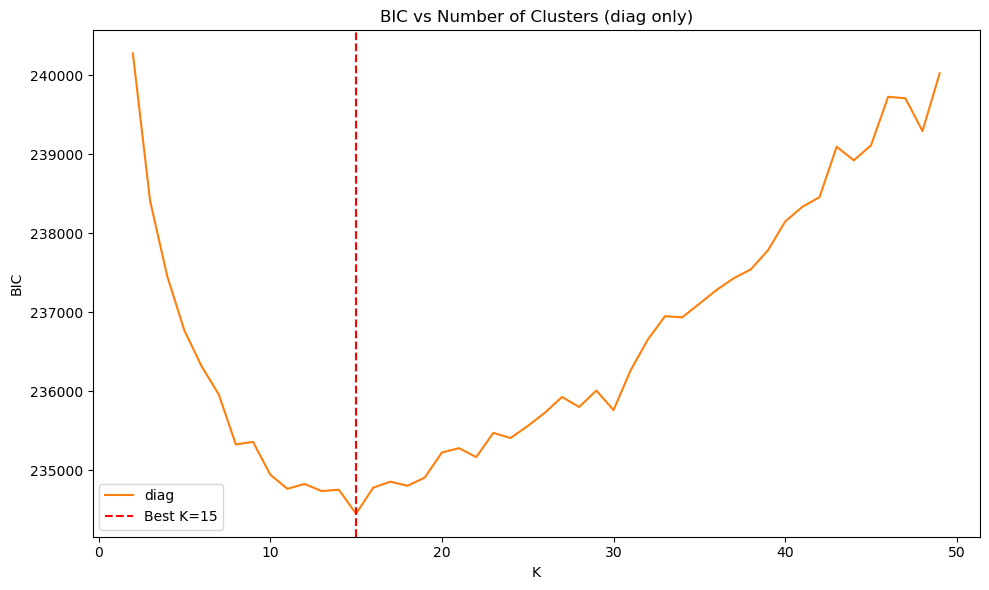

In [23]:
#BIC搜索GMM聚类
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
import umap
from sklearn.manifold import TSNE

# 输入: X_pca (n_segments, n_features)
X_pca = features_pca  

# 1. BIC 搜索，仅 diag

K_range = range(2, 50) #
best_bic = np.inf
best_gmm = None
bics = []

for K in K_range:
    gmm = GaussianMixture(
        n_components=K,
        covariance_type='diag',
        n_init=10,
        random_state=42
    )
    gmm.fit(X_pca)
    bic = gmm.bic(X_pca)
    bics.append(bic)
    
    if bic < best_bic:
        best_bic = bic
        best_gmm = gmm

labels = best_gmm.predict(X_pca)
print(f"最优: K={best_gmm.n_components}, cov=diag, BIC={best_bic:.1f}")

# 2. 绘制 BIC 曲线
plt.figure(figsize=(10, 6))
plt.plot(K_range, bics, color='tab:orange', label='diag')
plt.axvline(best_gmm.n_components, color='red', linestyle='--', label=f'Best K={best_gmm.n_components}')
plt.xlabel('K')
plt.ylabel('BIC')
plt.title('BIC vs Number of Clusters (diag only)')
plt.legend()
plt.tight_layout()
plt.show()


d:\Anaconda3\envs\Machinelearning\Lib\site-packages\umap\umap_.py:1401: RuntimeWarning: divide by zero encountered in power
  return 1.0 / (1.0 + a * x ** (2 * b))
d:\Anaconda3\envs\Machinelearning\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


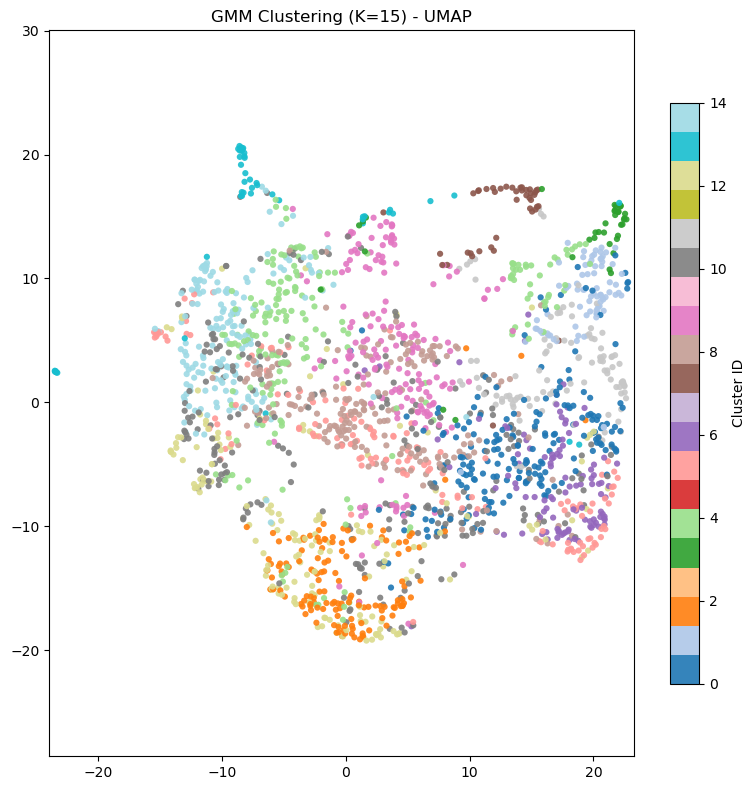

In [24]:
# UMAP聚类可视化
%matplotlib inline
reducer_umap = umap.UMAP(n_neighbors=5,
                        min_dist=0.4, 
                        random_state=12,
                        spread = 4.0
                        )
X_umap = reducer_umap.fit_transform(X_pca)

fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(
    X_umap[:, 0], 
    X_umap[:, 1], 
    c=labels, 
    cmap='tab20'[0:5], 
    s=20,              # 点更小
    marker='o',       # 实心圆
    linewidths=0,     # 无描边
    edgecolors='none',
    alpha=0.9
)

# 收紧坐标轴，消除空白边距，使图像更紧凑
ax.margins(0.01)
ax.set_aspect('equal', adjustable='datalim')

plt.colorbar(scatter, label='Cluster ID', shrink=0.8)
plt.title(f'GMM Clustering (K={best_gmm.n_components}) - UMAP')
plt.tight_layout()
plt.show()

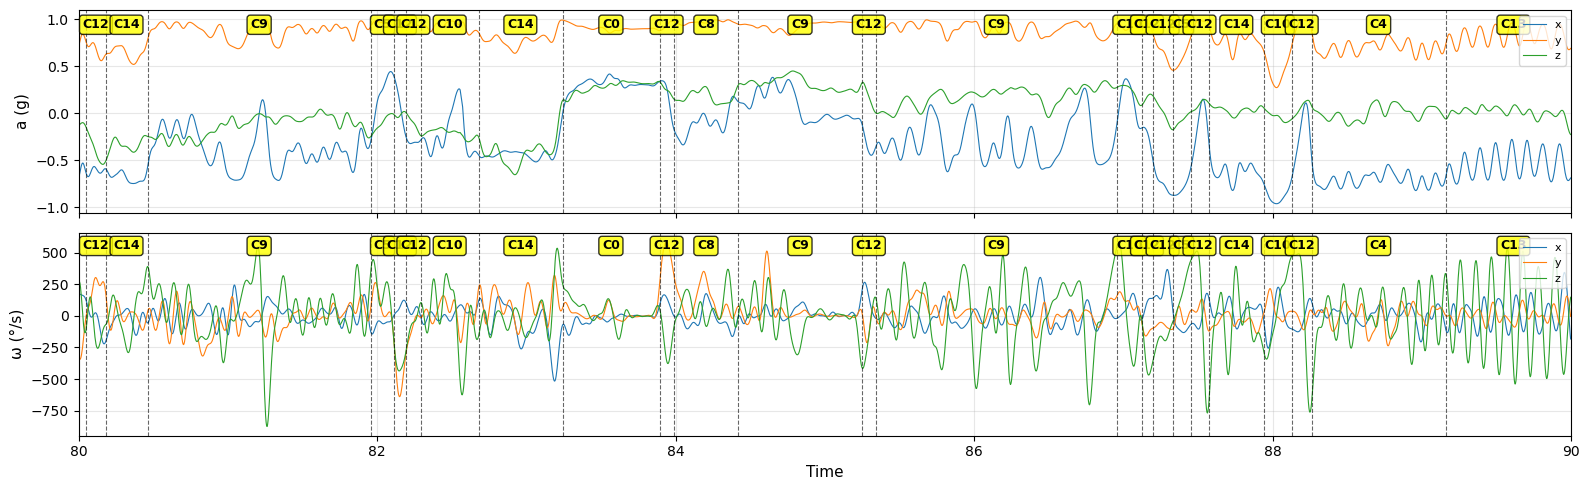

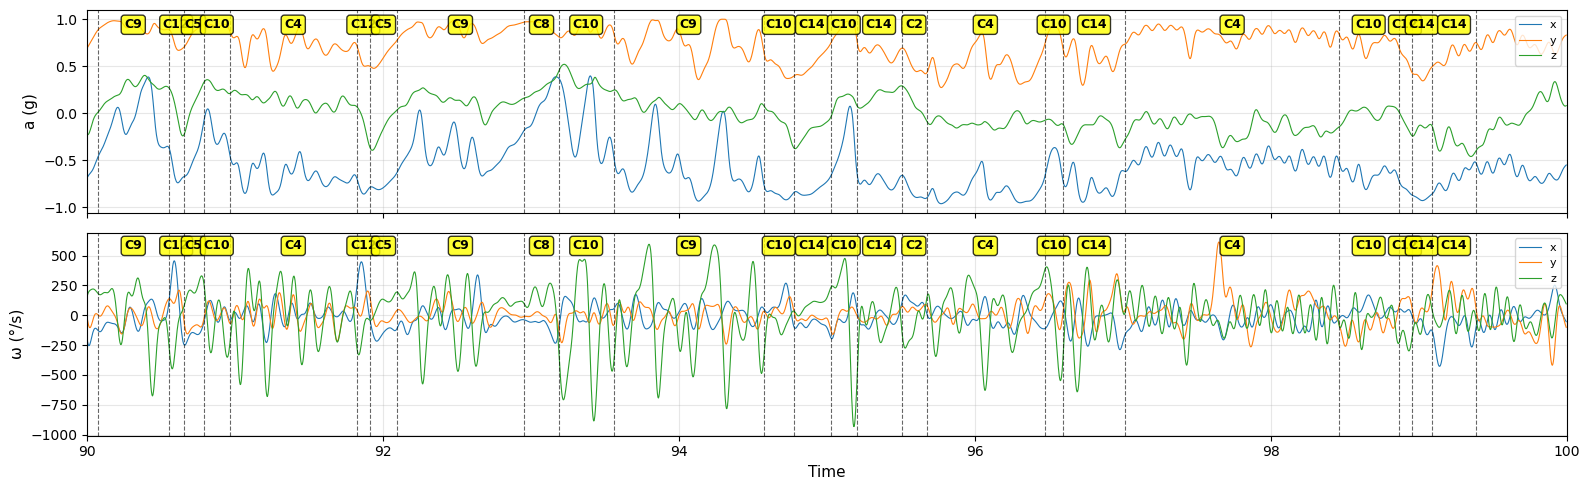

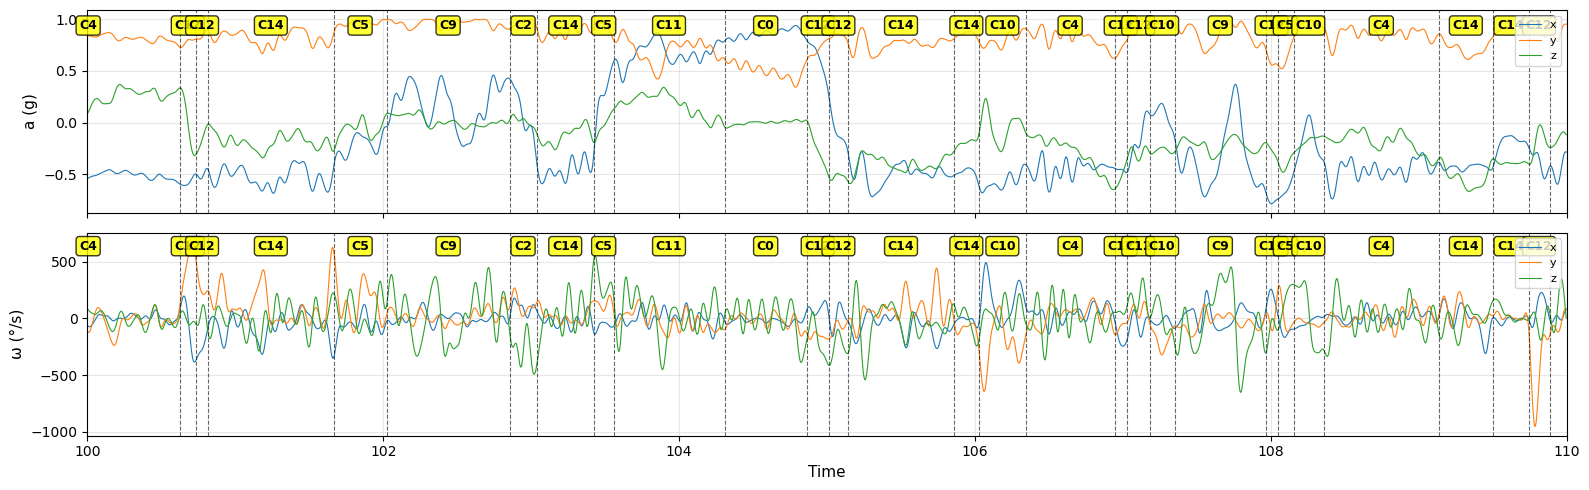

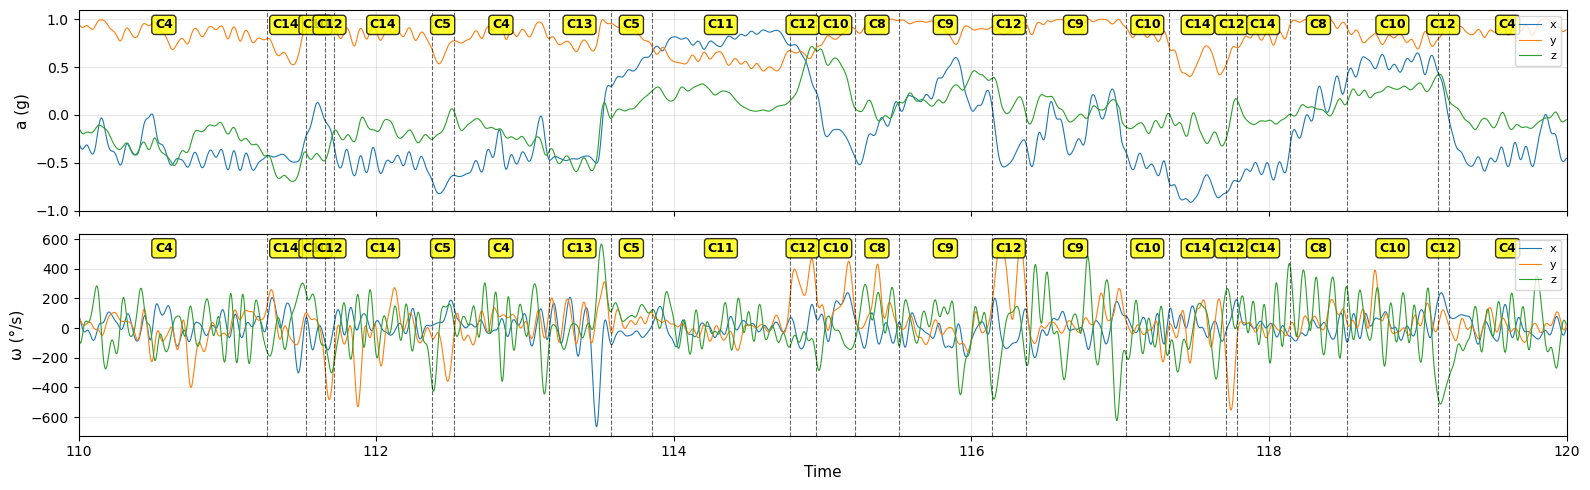

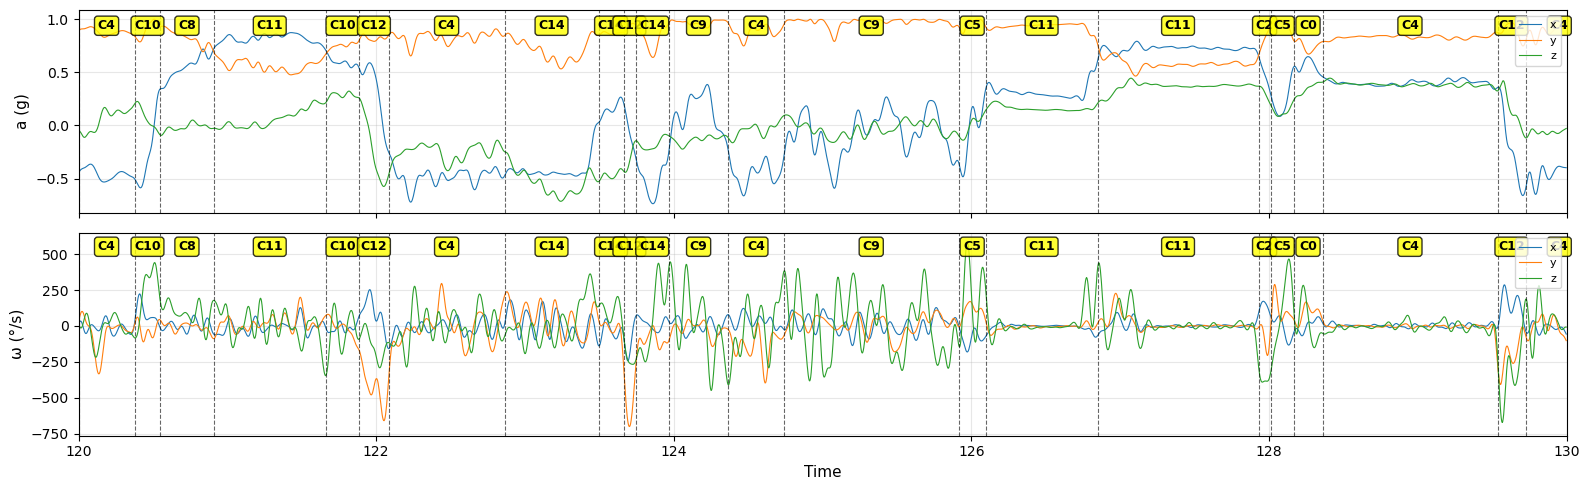

In [30]:
import numpy as np
import matplotlib.pyplot as plt

def plot_segments_with_labels(segments, labels, t_start=None, t_end=None, figsize=(16, 5)):
    """
    绘制带标签的 IMU 分段数据。

    Parameters
    ----------
    segments : list of np.ndarray
        每段 (m, 13)，第 0 列为时间戳，后 12 列为
        [aGx,aGy,aGz, anGx,anGy,anGz, wx,wy,wz, roll,pitch,yaw]。
    labels : array-like
        每段对应的类别标签。
    """
    # 拼接全部数据
    full = np.vstack(segments)
    t, data = full[:, 0], full[:, 1:]

    # 时间范围截断
    t0 = t_start if t_start is not None else t[0]
    t1 = t_end   if t_end   is not None else t[-1]
    mask = (t >= t0) & (t <= t1)
    t, data = t[mask], data[mask]

    # 收集与视图相交的片段边界和标签
    bounds = [(seg[0, 0], seg[-1, 0], int(lab))
              for seg, lab in zip(segments, labels)
              if seg[-1, 0] >= t0 and seg[0, 0] <= t1]

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)
    groups = [
        (data[:, 0:3], 'a (g)', ['x', 'y', 'z']),
        (data[:, 6:9], 'ω (°/s)', ['x', 'y', 'z']),
    ]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

    for ax, (d, title, names) in zip(axes, groups):
        for ch, c in enumerate(colors):
            ax.plot(t, d[:, ch], color=c, lw=0.8, label=names[ch])

        for b, _, _ in bounds:
            if t0 <= b <= t1:
                ax.axvline(b, color='k', ls='--', lw=0.8, alpha=0.6)

        y_top = ax.get_ylim()[1]
        for s, e, lab in bounds:
            mid = (s + e) / 2
            if t0 <= mid <= t1:
                ax.text(mid, y_top * 0.92, f'C{lab}',
                        ha='center', va='top', fontsize=9, fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.25', facecolor='yellow', alpha=0.8))

        ax.set_ylabel(title, fontsize=11)
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(t0, t1)

    axes[-1].set_xlabel('Time', fontsize=11)
    plt.tight_layout()
    plt.show()

for i in [80,90,100,110,120]:
# ========== 使用示例 ==========
    plot_segments_with_labels(
        segments=data1_CPDsegments,   # list of (m, 13)，每段第 0 列为时间戳
        labels=labels,
        t_start=i,
        t_end=i+10,
        figsize=(16, 5)
    )

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn import hmm

def fit_categorical_hmm_bic(labels, K, S_max=10, n_restarts=10):
    """
    按照原文方法拟合分类 HMM，通过 BIC 选择最优隐藏状态数 S。
    
    参数
    ----
    labels : np.ndarray, shape (N,)
        观测序列，每个元素为 0..K-1 的整数（cluster 标签）
    K : int
        观测类别数（clusters 数）
    S_max : int
        隐藏状态数搜索上限（原文 1–30）
    n_restarts : int
        每个 S 的随机初始化次数（原文 10 次）
        
    返回
    ----
    best_model : hmm.CategoricalHMM
    best_S : int
    best_bic : float
    state_sequence : np.ndarray, shape (N,)
        Viterbi 解码后的最优隐藏状态序列
    """
    # 确保输入格式
    Y = np.asarray(labels).flatten()
    if Y.min() < 0 or Y.max() >= K:
        raise ValueError("labels must be integers in range [0, K-1]")
    X = Y.reshape(-1, 1)
    N = len(Y)
    
    best_bic = -np.inf
    best_model = None
    best_S = None
    
    print("Searching optimal S via BIC...")
    for S in range(1, S_max + 1):
        bic_scores = []
        models = []
        
        for r in range(n_restarts):
            # 原文：100 次 EM 迭代，随机初始化
            model = hmm.CategoricalHMM(
                n_components=S,
                n_features=K,
                n_iter=100,
                random_state=None,
                init_params='ste'
            )
            try:
                model.fit(X)
                log_likelihood = model.score(X)
                
                # 参数数量 m_S（原文公式）
                # startprob: S-1, transmat: S*(S-1), emissionprob: S*(K-1)
                m_S = (S - 1) + S * (S - 1) + S * (K - 1)
                
                # BIC = 2*logL - m_S*log(N)
                bic = 2 * log_likelihood - m_S * np.log(N)
                bic_scores.append(bic)
                models.append(model)
            except Exception:
                bic_scores.append(-np.inf)
                models.append(None)
        
        idx_best = int(np.argmax(bic_scores))
        bic_best_S = bic_scores[idx_best]
        print(f"  S={S:2d}: best BIC={bic_best_S:.1f}")
        
        if bic_best_S > best_bic:
            best_bic = bic_best_S
            best_model = models[idx_best]
            best_S = S
    
    # Viterbi 解码（原文 E-step）
    state_sequence = best_model.predict(X)
    
    print(f"\nOptimal: S={best_S}, BIC={best_bic:.1f}")
    return best_model, best_S, best_bic, state_sequence


def visualize_hmm(model, labels, K, best_S, state_sequence, figsize=(14, 10)):
    """
    HMM 结果可视化，贴近原文 Fig 6 风格。
    """
    Y = np.asarray(labels).flatten()
    N = len(Y)
    
    E = model.emissionprob_          # (S, K)
    A = model.transmat_              # (S, S)
    
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1.2], hspace=0.35, wspace=0.3)
    
    # ---------- 子图 1: 发射概率矩阵 (类似 Fig 6A) ----------
    ax1 = fig.add_subplot(gs[0, :])
    im1 = ax1.imshow(E, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
    ax1.set_xlabel('Cluster ID', fontsize=11)
    ax1.set_ylabel('Hidden State', fontsize=11)
    ax1.set_title('Emission Probabilities  P(cluster | state)', fontsize=12, fontweight='bold')
    ax1.set_xticks(np.arange(K))
    ax1.set_yticks(np.arange(best_S))
    plt.colorbar(im1, ax=ax1, label='Probability')
    
    for i in range(best_S):
        for j in range(K):
            if E[i, j] > 0.15:
                ax1.text(j, i, f'{E[i,j]:.2f}', ha='center', va='center', 
                        color='white' if E[i,j] > 0.6 else 'black', fontsize=7)
    
    # ---------- 子图 2: 转移矩阵 (类似 Fig 6B) ----------
    ax2 = fig.add_subplot(gs[1, 0])
    im2 = ax2.imshow(A, aspect='auto', cmap='Greys', vmin=0, vmax=1)
    ax2.set_xlabel('To State', fontsize=11)
    ax2.set_ylabel('From State', fontsize=11)
    ax2.set_title('State Transition Matrix', fontsize=12, fontweight='bold')
    ax2.set_xticks(np.arange(best_S))
    ax2.set_yticks(np.arange(best_S))
    plt.colorbar(im2, ax=ax2, label='Probability')
    
    # ---------- 子图 3: 每个状态的主导 Cluster ----------
    ax3 = fig.add_subplot(gs[1, 1])
    dominant_clusters = np.argmax(E, axis=1)
    dominant_probs = np.max(E, axis=1)
    
    y_pos = np.arange(best_S)
    ax3.barh(y_pos, dominant_probs, color='steelblue', edgecolor='black')
    ax3.set_yticks(y_pos)
    ax3.set_yticklabels([f'State {i}' for i in range(best_S)])
    ax3.set_xlabel('Max Emission Probability', fontsize=11)
    ax3.set_title('Dominant Cluster per State', fontsize=12, fontweight='bold')
    ax3.set_xlim(0, 1)
    
    for i, (prob, clus) in enumerate(zip(dominant_probs, dominant_clusters)):
        ax3.text(prob + 0.02, i, f'C{clus}', va='center', fontsize=9, fontweight='bold')
    
    # ---------- 子图 4: 状态序列与观测序列 (类似 Fig 6D) ----------
    ax4 = fig.add_subplot(gs[2, :])
    
    show_n = min(N, 800)
    t = np.arange(show_n)
    
    ax4.scatter(t, Y[:show_n], c='lightgray', s=12, alpha=0.5, label='Cluster (GMM)', zorder=1)
    ax4.step(t, state_sequence[:show_n], where='mid', color='darkred', lw=2, label='Hidden State (HMM)', zorder=2)
    
    ax4.set_xlabel('Segment Index', fontsize=11)
    ax4.set_ylabel('State / Cluster ID', fontsize=11)
    ax4.set_title('State Sequence (Viterbi Decoding)', fontsize=12, fontweight='bold')
    ax4.legend(loc='upper right')
    ax4.set_ylim(-0.5, max(best_S, K) - 0.5)
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.show()
    
    # 打印映射表
    print("\n--- State-Cluster Mapping ---")
    for i in range(best_S):
        top3 = np.argsort(E[i])[::-1][:3]
        probs = E[i, top3]
        print(f"State {i:2d}: top clusters = {top3} (probs: {probs.round(3)})")


# ========== 使用示例 ==========
# 确保 labels 是 0-based 整数

best_model, best_S, best_bic, state_seq = fit_categorical_hmm_bic(
    labels= labels, 
    K=26, 
    S_max=10, 
    n_restarts=10
)


In [ ]:


def visualize_hmm(model, labels, K, best_S, state_sequence, cell_size=0.35):
    """
    HMM 结果可视化，保持矩阵原始比例（方形单元格），不纵向压缩。
    布局：发射矩阵与转移矩阵并排（各自单元格为正方形），
          主导图与序列图在下侧展开。
    """
    Y = np.asarray(labels).flatten()
    N = len(Y)
    E = model.emissionprob_
    A = model.transmat_
    
    # 动态 figsize：根据数据维度计算，确保单元格接近正方形
    # 发射矩阵 E: 宽 K, 高 S  |  转移矩阵 A: 宽 S, 高 S
    w0 = K * cell_size
    w1 = best_S * cell_size
    h0 = best_S * cell_size
    h1 = max(best_S * cell_size * 0.4, 3)
    h2 = 4
    
    fig = plt.figure(figsize=(w0 + w1 + 1.5, h0 + h1 + h2 + 1.5))
    gs = fig.add_gridspec(3, 2, 
                          width_ratios=[w0, w1], 
                          height_ratios=[h0, h1, h2],
                          hspace=0.4, wspace=0.35)
    
    # ---------- 子图 1: 发射概率矩阵 (S, K) ----------
    ax1 = fig.add_subplot(gs[0, 0])
    im1 = ax1.imshow(E, aspect='equal', cmap='YlOrRd', vmin=0, vmax=1)
    ax1.set_xlabel('Cluster ID', fontsize=11)
    ax1.set_ylabel('Hidden State', fontsize=11)
    ax1.set_title('Emission Probabilities P(cluster|state)', fontsize=12, fontweight='bold')
    ax1.set_xticks(np.arange(K))
    ax1.set_yticks(np.arange(best_S))
    plt.colorbar(im1, ax=ax1, label='Probability', shrink=0.8)
    
    for i in range(best_S):
        for j in range(K):
            if E[i, j] > 0.15:
                ax1.text(j, i, f'{E[i,j]:.2f}', ha='center', va='center', 
                        color='white' if E[i,j] > 0.6 else 'black', fontsize=7)
    
    # ---------- 子图 2: 转移矩阵 (S, S) 方形 ----------
    ax2 = fig.add_subplot(gs[0, 1])
    im2 = ax2.imshow(A, aspect='equal', cmap='Greys', vmin=0, vmax=1)
    ax2.set_xlabel('To State', fontsize=11)
    ax2.set_ylabel('From State', fontsize=11)
    ax2.set_title('State Transition Matrix', fontsize=12, fontweight='bold')
    ax2.set_xticks(np.arange(best_S))
    ax2.set_yticks(np.arange(best_S))
    plt.colorbar(im2, ax=ax2, label='Probability', shrink=0.8)
    
    # ---------- 子图 3: 主导 Cluster（跨两列） ----------
    ax3 = fig.add_subplot(gs[1, :])
    dominant_clusters = np.argmax(E, axis=1)
    dominant_probs = np.max(E, axis=1)
    y_pos = np.arange(best_S)
    ax3.barh(y_pos, dominant_probs, color='steelblue', edgecolor='black')
    ax3.set_yticks(y_pos)
    ax3.set_yticklabels([f'State {i}' for i in range(best_S)])
    ax3.set_xlabel('Max Emission Probability', fontsize=11)
    ax3.set_title('Dominant Cluster per State', fontsize=12, fontweight='bold')
    ax3.set_xlim(0, 1)
    for i, (prob, clus) in enumerate(zip(dominant_probs, dominant_clusters)):
        ax3.text(prob + 0.02, i, f'C{clus}', va='center', fontsize=9, fontweight='bold')
    
    # ---------- 子图 4: 状态序列（跨两列） ----------
    ax4 = fig.add_subplot(gs[2, :])
    show_n = min(N, 800)
    t = np.arange(show_n)
    ax4.scatter(t, Y[:show_n], c='lightgray', s=12, alpha=0.5, label='Cluster (GMM)', zorder=1)
    ax4.step(t, state_sequence[:show_n], where='mid', color='darkred', lw=2, label='Hidden State (HMM)', zorder=2)
    ax4.set_xlabel('Segment Index', fontsize=11)
    ax4.set_ylabel('State / Cluster ID', fontsize=11)
    ax4.set_title('State Sequence (Viterbi Decoding)', fontsize=12, fontweight='bold')
    ax4.legend(loc='upper right')
    ax4.set_ylim(-0.5, max(best_S, K) - 0.5)
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # 打印映射表
    print("\n--- State-Cluster Mapping ---")
    for i in range(best_S):
        top3 = np.argsort(E[i])[::-1][:3]
        probs = E[i, top3]
        print(f"State {i:2d}: top clusters = {top3} (probs: {probs.round(3)})")


# ========== 使用示例 ==========
# best_model, best_S, best_bic, state_seq = fit_categorical_hmm_bic(
#     labels=labels, K=11, S_max=15, n_restarts=10
# )
# visualize_hmm(best_model, labels, 11, best_S, state_seq, cell_size=0.35)
visualize_hmm(best_model, labels_gmm, 15, best_S, state_seq)

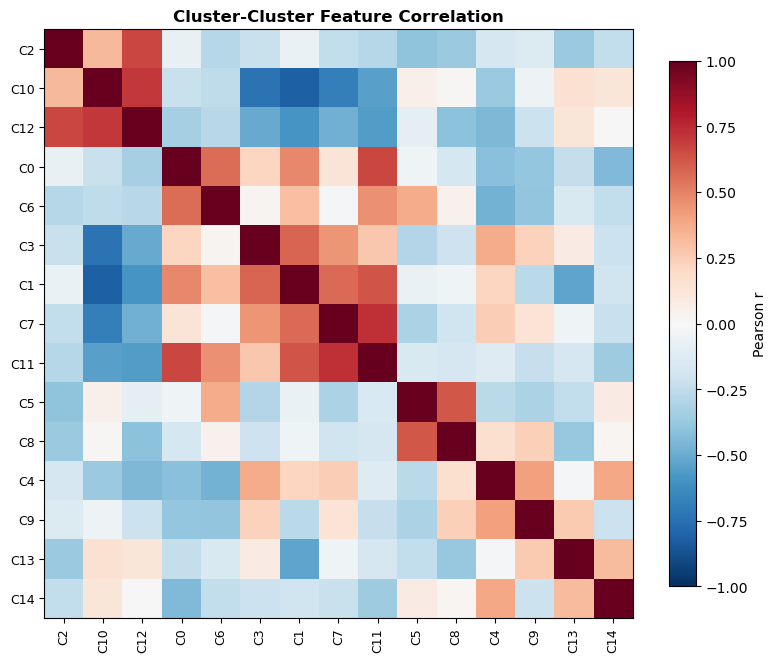

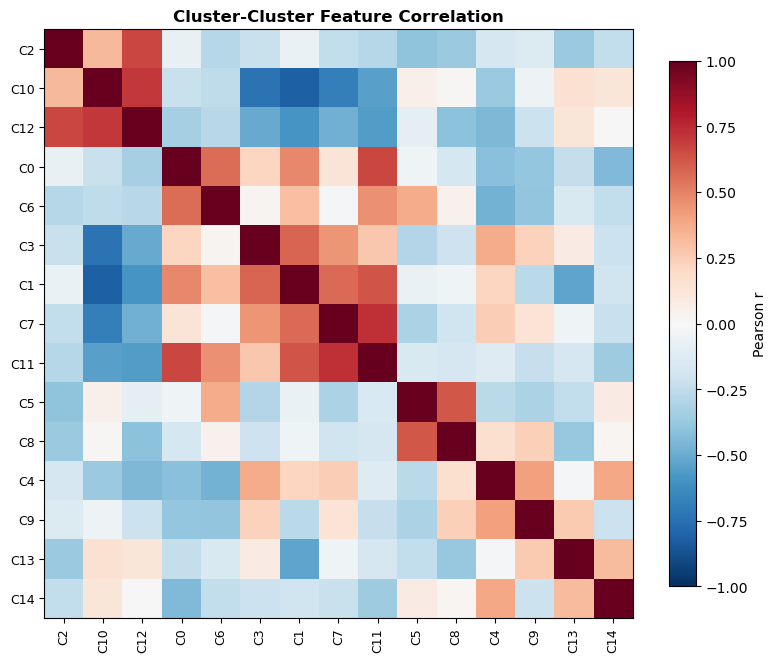

重排顺序: [2, 10, 12, 0, 6, 3, 1, 7, 11, 5, 8, 4, 9, 13, 14]


In [33]:
#绘制特征相关性矩阵
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

def compute_cluster_feature_correlation(features, labels):
    """
    计算不同 Cluster 之间的特征相关性矩阵。
    """
    labels = np.asarray(labels).flatten()
    unique_labels = sorted(np.unique(labels))
    K = len(unique_labels)
    
    # 计算每个 Cluster 的特征均值
    cluster_means = np.zeros((K, features.shape[1]))
    for i, k in enumerate(unique_labels):
        mask = labels == k
        cluster_means[i] = np.mean(features[mask], axis=0)
    
    # 计算 K 个均值向量之间的 Pearson 相关矩阵
    cluster_corr = np.corrcoef(cluster_means)
    
    return cluster_corr, cluster_means, unique_labels


def plot_cluster_correlation_ordered(cluster_corr, title='Cluster-Cluster Feature Correlation'):
    """
    绘制 Cluster 间相关性热力图，使用层次聚类重排顺序，使相似 Cluster 相邻。
    不显示色块数值。
    """
    K = cluster_corr.shape[0]
    
    # 1. 将相关矩阵转为距离矩阵（1 - |r| 或 1 - r），用于层次聚类
    # 使用 1 - r 保持正负相关性结构，使正相关的 cluster 聚在一起
    dist_matrix = 1.0 - cluster_corr
    
    # 2. 层次聚类获取重排顺序
    # squareform 将方阵转为压缩向量，linkage 计算层次树
    condensed_dist = squareform(dist_matrix, checks=False)
    Z = linkage(condensed_dist, method='average')  # average linkage
    dn = dendrogram(Z, no_plot=True)
    order = dn['leaves']  # 重排后的索引顺序
    
    # 3. 按新顺序重排相关矩阵
    corr_ordered = cluster_corr[order][:, order]
    
    # 4. 绘制热图
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(corr_ordered, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
    
    # 设置刻度标签为新顺序
    ordered_labels = [f'C{order[i]}' for i in range(K)]
    ax.set_xticks(np.arange(K))
    ax.set_yticks(np.arange(K))
    ax.set_xticklabels(ordered_labels, rotation=90, fontsize=9)
    ax.set_yticklabels(ordered_labels, fontsize=9)
    
    # 不显示数值
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Pearson r', shrink=0.8)
    plt.tight_layout()
    plt.show()
    
    return order


# ========== 使用示例 ==========
cluster_corr, cluster_means, unique_labels = compute_cluster_feature_correlation(
    features=np.array(features_pca),
    labels=labels
)
order = plot_cluster_correlation_ordered(cluster_corr)
print("重排顺序:", order)

In [31]:
import os
import cv2
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


def plot_imu_6axis(seg_data, save_path):
    """
    绘制 6 轴 IMU 图像。
    
    seg_data : np.ndarray
        (m, 13)：第 0 列为时间戳，后 12 列为
        [aGx,aGy,aGz, anGx,anGy,anGz, wx,wy,wz, roll,pitch,yaw]。
        兼容 (m, 6) 和 (m, 9+) 的旧格式。
    """
    n_cols = seg_data.shape[1]

    if n_cols == 13:
        t = seg_data[:, 0]
        acc = seg_data[:, 1:4]
        gyr = seg_data[:, 7:10]
    elif n_cols == 6:
        t = np.arange(len(seg_data))
        acc = seg_data[:, 0:3]
        gyr = seg_data[:, 3:6]
    elif n_cols >= 9:
        t = np.arange(len(seg_data))
        acc = seg_data[:, 0:3]
        gyr = seg_data[:, 6:9]
    else:
        raise ValueError(f"seg_data 列数 {n_cols} 不符合预期 (6, 9+, 13)")

    fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True,
                             gridspec_kw={'hspace': 0.05})

    for ch, c in enumerate(['#1f77b4', '#ff7f0e', '#2ca02c']):
        axes[0].plot(t, acc[:, ch], label=['x', 'y', 'z'][ch], color=c, lw=0.9)
    axes[0].set_ylabel('aG (g)')
    axes[0].legend(loc='upper right', fontsize=8)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_title(os.path.basename(save_path).replace('.png', ''), fontsize=9)

    for ch, c in enumerate(['#d62728', '#9467bd', '#8c564b']):
        axes[1].plot(t, gyr[:, ch], label=['x', 'y', 'z'][ch], color=c, lw=0.9)
    axes[1].set_ylabel('ω (°/s)')
    axes[1].set_xlabel('Time (s)')
    axes[1].legend(loc='upper right', fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close(fig)


def split_video_by_clusters(video_path, data_segments, cluster_labels,
                            output_dir, save_imu_plots=True):
    """
    根据聚类标签将视频分割成片段，并可选同步保存 6 轴 IMU 图像。

    Parameters
    ----------
    data_segments : list of np.ndarray
        每段 (m, 13)，第 0 列为时间戳，后 12 列为 IMU 数据。
    cluster_labels : array-like
        每段对应的聚类标签。
    """
    # 直接从每段时间戳获取起止时间
    seg_info = []
    for i, seg in enumerate(data_segments):
        seg_info.append({
            'seg_id': i,
            't_start': seg[0, 0],
            't_end': seg[-1, 0],
            'cluster': int(cluster_labels[i]),
        })

    # 打开视频
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise IOError(f"无法打开视频: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # 创建输出目录
    os.makedirs(output_dir, exist_ok=True)
    for c in sorted({s['cluster'] for s in seg_info}):
        os.makedirs(os.path.join(output_dir, f"cluster_{c}"), exist_ok=True)

    # 逐段裁剪 + 绘图
    for seg in tqdm(seg_info, desc="Splitting video & plotting IMU"):
        sid = seg['seg_id']
        cluster = seg['cluster']
        t0, t1 = seg['t_start'], seg['t_end']

        # 视频裁剪
        f0 = max(0, int(np.floor(t0 * fps)))
        f1 = min(total_frames, int(np.ceil(t1 * fps)) + 1)
        n_frames = f1 - f0
        if n_frames <= 0:
            continue

        base = f"seg{sid:04d}_{t0:.3f}s_{t1:.3f}s"
        out_path = os.path.join(output_dir, f"cluster_{cluster}", base + ".mp4")

        out = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
        cap.set(cv2.CAP_PROP_POS_FRAMES, f0)
        for _ in range(n_frames):
            ret, frame = cap.read()
            if not ret:
                break
            out.write(frame)
        out.release()

        # 同步保存 IMU 图
        if save_imu_plots:
            img_path = os.path.join(output_dir, f"cluster_{cluster}", base + ".png")
            plot_imu_6axis(data_segments[sid], img_path)

    cap.release()
    print(f"完成，共 {len(seg_info)} 个片段，保存到: {output_dir}")
    return output_dir


# ==================== 使用示例 ====================
output_dir = split_video_by_clusters(
    video_path="F:/IMU_computational_ethology/Data/LSD/LSD_data2_x264.mp4",
    data_segments=data1_CPDsegments,   # list of (m, 13)，每段第 0 列为时间戳
    cluster_labels=labels,
    output_dir=r"F:/IMU_computational_ethology/Data/LSD/Cluster_Clips_resampled_new",
)

Splitting video & plotting IMU:   0%|          | 0/2065 [00:00<?, ?it/s]C:\Users\Shubai\AppData\Local\Temp\ipykernel_16136\2251978927.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
Splitting video & plotting IMU: 100%|██████████| 2065/2065 [33:58<00:00,  1.01it/s]

完成，共 2065 个片段，保存到: F:/IMU_computational_ethology/Data/LSD/Cluster_Clips_resampled_new


In [ ]:
import os
import cv2
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

def crop_video_and_data(video_path, data_segments, timestamps, duration_sec=120.0):
    """
    按 IMU 时间戳起点对齐，裁剪视频和前 duration_sec 秒的 IMU 数据。
    """
    full_data = np.vstack(data_segments)
    full_times = np.asarray(timestamps).flatten()
    
    t_start = full_times[0]
    t_end_crop = t_start + duration_sec
    
    idx_end = np.searchsorted(full_times, t_end_crop)
    idx_end = min(idx_end, len(full_times))
    
    cropped_segments = []
    total_samples = 0
    for seg in data_segments:
        seg_len = len(seg)
        if total_samples >= idx_end:
            break
        if total_samples + seg_len <= idx_end:
            cropped_segments.append(seg)
        else:
            cropped_segments.append(seg[:idx_end - total_samples])
        total_samples += seg_len
    
    cropped_times = full_times[:idx_end]
    
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    frame_start = max(0, int(np.floor(t_start * fps)))
    frame_end = min(total_frames, int(np.ceil(t_end_crop * fps)) + 1)
    n_frames_crop = frame_end - frame_start
    
    if frame_start > 0:
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_start)
    
    dir_name = os.path.dirname(video_path)
    base_name = os.path.basename(video_path)
    name, ext = os.path.splitext(base_name)
    cropped_video_path = os.path.join(dir_name, f"{name}_2min_aligned{ext}")
    
    out = cv2.VideoWriter(cropped_video_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
    for _ in tqdm(range(n_frames_crop), desc="Cropping video"):
        ret, frame = cap.read()
        if not ret:
            break
        out.write(frame)
    
    out.release()
    cap.release()
    print(f"Saved: {cropped_video_path}")
    return cropped_video_path, cropped_segments, cropped_times

import os
import cv2
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


def render_hmm_cluster_video(video_path, data_segments, timestamps, 
                             state_sequence, cluster_labels,
                             window_sec=4.0, step=2, plot_dpi=80):
    """
    将 HMM 隐藏状态 和 GMM 聚类类别 同时合成到视频上。
    若 state_sequence / cluster_labels 长度超过 data_segments，自动截取前 N 段。
    """
    # ===== 截取标签：只保留与 data_segments 对应的片段 =====
    n_segs = len(data_segments)
    state_sequence = np.asarray(state_sequence)[:n_segs]
    cluster_labels = np.asarray(cluster_labels)[:n_segs]
    
    full_data = np.vstack(data_segments)
    full_times = np.asarray(timestamps).flatten()
    full_times = full_times - full_times[0]
    n_total = len(full_times)
    
    S = int(np.max(state_sequence)) + 1
    K = int(np.max(cluster_labels)) + 1
    
    # 计算每段起止时间
    seg_info = []
    idx = 0
    for i, seg in enumerate(data_segments):
        m = len(seg)
        seg_info.append({
            'start_idx': idx,
            'end_idx': idx + m,
            't_start': full_times[idx],
            't_end': full_times[idx + m - 1] if m > 1 else full_times[idx],
            'state': int(state_sequence[i]),
            'cluster': int(cluster_labels[i]),
            'seg_id': i
        })
        idx += m
    
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    t_start = 0.0
    t_end = full_times[-1]
    frame_start = 0
    frame_end = total_frames
    
    dir_name = os.path.dirname(video_path)
    base_name = os.path.basename(video_path)
    out_path = os.path.join(dir_name, "hmm_cluster_" + base_name)
    
    wave_h = 320
    progress_h = 80
    total_plot_h = wave_h + progress_h
    
    out_fps = fps / step
    out = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'mp4v'), out_fps, (w, h + total_plot_h))
    
    half = window_sec / 2.0
    
    # 预计算每帧对应的 segment
    n_frames = frame_end - frame_start
    frame_times_all = (np.arange(frame_start, frame_end) + 0.5) / fps
    
    seg_starts = np.array([s['t_start'] for s in seg_info])
    seg_ends = np.array([s['t_end'] for s in seg_info])
    seg_states_arr = np.array([s['state'] for s in seg_info])
    seg_clusters_arr = np.array([s['cluster'] for s in seg_info])
    seg_ids_arr = np.array([s['seg_id'] for s in seg_info])
    
    frame_seg_idx = np.searchsorted(seg_starts, frame_times_all, side='right') - 1
    frame_seg_idx = np.clip(frame_seg_idx, 0, len(seg_info) - 1)
    valid_mask = (frame_times_all >= seg_starts[frame_seg_idx]) & (frame_times_all <= seg_ends[frame_seg_idx])
    frame_seg_idx[~valid_mask] = -1
    
    # 颜色映射
    cmap_state = plt.cm.get_cmap('tab20', max(S, 20))
    cmap_cluster = plt.cm.get_cmap('tab20b', max(K, 20))
    state_colors = {s: cmap_state(i) for i, s in enumerate(sorted(set(seg_states_arr)))}
    cluster_colors = {k: cmap_cluster(i) for i, k in enumerate(sorted(set(seg_clusters_arr)))}
    
    process_frames = np.arange(frame_start, frame_end, step)
    
    for fi in tqdm(process_frames, desc="Rendering", total=len(process_frames)):
        t = fi / fps
        
        cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
        ret, frame = cap.read()
        if not ret:
            continue
        
        # IMU 窗口
        i0 = np.searchsorted(full_times, t - half)
        i1 = np.searchsorted(full_times, t + half)
        i0 = max(0, i0)
        i1 = min(n_total, i1)
        tw = full_times[i0:i1]
        dw = full_data[i0:i1, :]
        if len(tw) < 2:
            continue
        
        # 查当前 segment
        seg_idx = frame_seg_idx[fi - frame_start]
        if seg_idx >= 0:
            curr_state = int(seg_states_arr[seg_idx])
            curr_cluster = int(seg_clusters_arr[seg_idx])
            curr_seg_id = int(seg_ids_arr[seg_idx])
        else:
            curr_state = -1
            curr_cluster = -1
            curr_seg_id = -1
        
        # 绘制
        fig = plt.figure(figsize=(w / 150, total_plot_h / 150), dpi=plot_dpi)
        gs = fig.add_gridspec(3, 1, height_ratios=[1, 1, 0.45], hspace=0.08)
        
        ax1 = fig.add_subplot(gs[0])
        ax2 = fig.add_subplot(gs[1])
        ax3 = fig.add_subplot(gs[2])
        
        # --- aG 1-3 ---
        colors_aG = ['#1f77b4', '#ff7f0e', '#2ca02c']
        for ch in range(3):
            ax1.plot(tw, dw[:, ch], color=colors_aG[ch], lw=1.2, label=f'aG{ch+1}')
        ax1.axvline(t, color='red', lw=2, zorder=5)
        for s in seg_info:
            if t - half <= s['t_start'] <= t + half:
                ax1.axvline(s['t_start'], color='black', linestyle='--', lw=0.8, alpha=0.5)
        ax1.set_xlim(t - half, t + half)
        ax1.set_ylim(-2, 2)
        ax1.set_ylabel('a (g)', fontsize=10)
        ax1.set_xticks([])
        ax1.legend(loc='upper left', fontsize=7)
        
        # --- 角度 7-9 ---
        colors_ang = ['#d62728', '#9467bd', '#8c564b']
        for ch in range(3):
            ax2.plot(tw, dw[:, ch + 6], color=colors_ang[ch], lw=1.2, label=f'Ω{ch+1}')
        ax2.axvline(t, color='red', lw=2, zorder=5)
        for s in seg_info:
            if t - half <= s['t_start'] <= t + half:
                ax2.axvline(s['t_start'], color='black', linestyle='--', lw=0.8, alpha=0.5)
        ax2.set_xlim(t - half, t + half)
        ax2.set_ylim(-400, 400)
        ax2.set_ylabel('Ω (°/s)', fontsize=10)
        ax2.set_xlabel('Time (s)', fontsize=10)
        ax2.legend(loc='upper left', fontsize=7)
        
        # --- 大标签：同时显示 State + Cluster ---
        if curr_state >= 0:
            state_color = state_colors.get(curr_state, 'yellow')
            label_text = f"Seg {curr_seg_id} | State {curr_state} | Cluster {curr_cluster}"
            for ax in [ax1, ax2]:
                ax.text(
                    0.98, 0.95, label_text,
                    transform=ax.transAxes,
                    fontsize=14, color='darkred', fontweight='bold',
                    ha='right', va='top',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor=state_color, alpha=0.85,
                              edgecolor='darkred', linewidth=2)
                )
        
        # --- 底部双层滚动条 ---
        ax3.set_xlim(t_start, t_end)
        ax3.set_ylim(0, 1)
        ax3.axis('off')
        
        # 上层：HMM State（y=0.5~1.0）
        for s in seg_info:
            color = state_colors.get(s['state'], 'gray')
            ax3.axvspan(s['t_start'], s['t_end'], ymin=0.5, ymax=1.0, 
                        color=color, alpha=0.6, zorder=1)
        
        # 下层：GMM Cluster（y=0.0~0.5）
        for s in seg_info:
            color = cluster_colors.get(s['cluster'], 'gray')
            ax3.axvspan(s['t_start'], s['t_end'], ymin=0.0, ymax=0.5, 
                        color=color, alpha=0.6, zorder=1)
        
        # 当前窗口高亮
        ax3.axvspan(t - half, t + half, color='white', alpha=0.25, zorder=2)
        ax3.axvline(t, color='red', lw=2, zorder=5)
        
        # 图例文字
        ax3.text(t_start + (t_end - t_start) * 0.02, 0.75, 'HMM State', 
                 fontsize=9, va='center', color='white', fontweight='bold')
        ax3.text(t_start + (t_end - t_start) * 0.02, 0.25, 'GMM Cluster', 
                 fontsize=9, va='center', color='white', fontweight='bold')
        
        ax3.set_xticks(np.linspace(t_start, t_end, 5))
        ax3.set_xticklabels([f'{x:.1f}s' for x in np.linspace(t_start, t_end, 5)], fontsize=8)
        
        fig.canvas.draw()
        
        buf = fig.canvas.buffer_rgba()
        plot_img = np.frombuffer(buf, dtype=np.uint8)
        plot_img = plot_img.reshape(fig.canvas.get_width_height()[::-1] + (4,))
        plot_img = plot_img[:, :, :3]
        plot_img = cv2.cvtColor(plot_img, cv2.COLOR_RGB2BGR)
        plt.close(fig)
        
        if plot_img.shape[1] != w or plot_img.shape[0] != total_plot_h:
            plot_img = cv2.resize(plot_img, (w, total_plot_h))
        
        combined = np.vstack([frame, plot_img])
        out.write(combined)
    
    out.release()
    cap.release()
    print(f"Saved: {out_path}")
    return out_path

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm


def extract_state_video_clips(video_path, data_segments, timestamps,
                              state_sequence, cluster_labels=None,
                              output_dir=None,
                              start_time=None, end_time=None,
                              min_duration_sec=0.5):
    """
    先按时间范围截取视频，再按 HMM States 切分片段。
    相邻且标签相同的 State 自动合并为一个视频片段。
    每个 State 的视频单独放在一个文件夹中。

    Parameters
    ----------
    video_path : str
        输入视频路径
    data_segments : list of ndarray
        数据片段列表
    timestamps : list/array
        各采样点的时间戳
    state_sequence : list/array
        每个 segment 对应的 HMM State
    cluster_labels : list/array, optional
        每个 segment 对应的 Cluster 标签（仅用于命名）
    output_dir : str, optional
        输出根目录，默认在视频同级目录创建 state_clips/
    start_time : float, optional
        截取起始时间（秒），默认从视频开头
    end_time : float, optional
        截取结束时间（秒），默认到视频结尾
    min_duration_sec : float
        低于此时长的片段将被跳过（秒）

    Returns
    -------
    tuple
        (output_paths, state_groups)
        output_paths : list 所有生成的视频路径
        state_groups : dict {state: [paths]} 按 State 分组的路径
    """
    # ===== 截取标签，与 data_segments 对齐 =====
    n_segs = len(data_segments)
    state_sequence = np.asarray(state_sequence)[:n_segs]
    if cluster_labels is not None:
        cluster_labels = np.asarray(cluster_labels)[:n_segs]
    else:
        cluster_labels = np.full(n_segs, -1)

    full_times = np.asarray(timestamps).flatten()
    full_times = full_times - full_times[0]

    # 计算每段起止时间
    seg_info = []
    idx = 0
    for i, seg in enumerate(data_segments):
        m = len(seg)
        t_start = full_times[idx]
        t_end = full_times[idx + m - 1] if m > 1 else full_times[idx]
        seg_info.append({
            't_start': t_start,
            't_end': t_end,
            'state': int(state_sequence[i]),
            'cluster': int(cluster_labels[i]),
            'seg_id': i
        })
        idx += m

    # 打开视频获取信息
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"无法打开视频: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    video_duration = total_frames / fps
    cap.release()

    # 应用时间范围过滤
    if start_time is None:
        start_time = 0.0
    if end_time is None:
        end_time = video_duration

    # 只保留在时间范围内的 segment，并裁剪到边界
    filtered_seg_info = []
    for s in seg_info:
        # 完全在时间范围外则跳过
        if s['t_end'] < start_time or s['t_start'] > end_time:
            continue
        s_copy = s.copy()
        s_copy['t_start'] = max(s['t_start'], start_time)
        s_copy['t_end'] = min(s['t_end'], end_time)
        filtered_seg_info.append(s_copy)

    seg_info = filtered_seg_info

    if len(seg_info) == 0:
        print("警告：指定时间范围内没有有效的 segment")
        return [], {}

    # 输出目录
    if output_dir is None:
        output_dir = os.path.join(os.path.dirname(video_path), "state_clips")
    os.makedirs(output_dir, exist_ok=True)

    base_name = os.path.splitext(os.path.basename(video_path))[0]

    # ===== 合并相邻相同 State 的片段 =====
    merged_clips = []
    current = {
        't_start': seg_info[0]['t_start'],
        't_end': seg_info[0]['t_end'],
        'state': seg_info[0]['state'],
        'cluster': seg_info[0]['cluster'],
        'seg_start_id': seg_info[0]['seg_id'],
        'seg_end_id': seg_info[0]['seg_id']
    }

    for s in seg_info[1:]:
        if s['state'] == current['state']:
            # 相邻且 state 相同，合并
            current['t_end'] = s['t_end']
            current['seg_end_id'] = s['seg_id']
        else:
            merged_clips.append(current)
            current = {
                't_start': s['t_start'],
                't_end': s['t_end'],
                'state': s['state'],
                'cluster': s['cluster'],
                'seg_start_id': s['seg_id'],
                'seg_end_id': s['seg_id']
            }
    merged_clips.append(current)

    # ===== 逐段截取视频（按时间顺序，单次打开视频） =====
    output_paths = []
    clip_idx = 0
    state_groups = {}

    cap = cv2.VideoCapture(video_path)

    for clip in tqdm(merged_clips, desc="Extracting clips"):
        t0 = clip['t_start']
        t1 = clip['t_end']
        state = clip['state']
        cluster = clip['cluster']
        seg_start = clip['seg_start_id']
        seg_end = clip['seg_end_id']

        # 时长过滤
        duration = t1 - t0
        if duration < min_duration_sec:
            continue

        # 边界保护
        t0 = max(start_time, t0)
        t1 = min(end_time, t1)
        if t1 <= t0:
            continue

        # 时间转帧号
        frame_start = int(t0 * fps)
        frame_end = int(t1 * fps)
        frame_start = max(0, frame_start)
        frame_end = min(total_frames, frame_end)

        if frame_end <= frame_start:
            continue

        # 创建 State 子文件夹
        state_dir = os.path.join(output_dir, f"State_{state}")
        os.makedirs(state_dir, exist_ok=True)

        # 构建文件名
        if cluster >= 0:
            fname = (f"{base_name}_clip{clip_idx:03d}_"
                     f"state{state}_cluster{cluster}_"
                     f"seg{seg_start}to{seg_end}_"
                     f"{t0:.2f}s-{t1:.2f}s.mp4")
        else:
            fname = (f"{base_name}_clip{clip_idx:03d}_"
                     f"state{state}_"
                     f"seg{seg_start}to{seg_end}_"
                     f"{t0:.2f}s-{t1:.2f}s.mp4")

        out_path = os.path.join(state_dir, fname)

        # 写入视频
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(out_path, fourcc, fps, (w, h))

        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_start)
        for _ in range(frame_end - frame_start):
            ret, frame = cap.read()
            if not ret:
                break
            out.write(frame)

        out.release()

        output_paths.append(out_path)
        state_groups.setdefault(state, []).append(out_path)
        clip_idx += 1

    cap.release()

    print(f"\n完成！共生成 {len(output_paths)} 个视频片段")
    for state, paths in sorted(state_groups.items()):
        print(f"  State {state}: {len(paths)} 个片段 -> {os.path.join(output_dir, f'State_{state}')}")

    return output_paths, state_groups

In [ ]:
# 只截取 10~60 秒范围内的视频，再按 State 切分
clips, groups = extract_state_video_clips(
    video_path="F:/IMU_computational_ethology/Data/LSD/LSD_data1.mp4",
    data_segments=data1_CPDsegments,
    timestamps=t1_CPDsegments,
    state_sequence=state_seq,
    cluster_labels=labels,
    output_dir="F:/IMU_computational_ethology/Data/LSD/StateClips",
    start_time=60.0,      # 从第 10 秒开始
    end_time=.0,        # 到第 60 秒结束
    min_duration_sec=0.3
)

# 查看 State 0 的所有片段
print(groups[0])

In [ ]:
# ========== 使用示例 ==========
# 1. 裁剪前 2 分钟
cropped_video, cropped_segments, cropped_times = crop_video_and_data(
    video_path="F:/IMU_computational_ethology/Data/LSD/LSD_data2.mp4",
    data_segments=data1_CPDsegments,
    timestamps=t1_CPDsegments,
    duration_sec=120.0
)




In [ ]:
import os
import cv2
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

def cut_video_by_cluster(video_path, data_segments, timestamps, cluster_labels, 
                         output_dir, duration_sec=None, t_start_offset=0.0, fs=100.0):
    """
    先截取视频和 IMU 数据的前 n 秒，再按 Cluster 标签切割视频片段，
    并为每段生成 aG(0-3) 和 ω(6-9) 信号静态图，横轴比例一致。
    """
    full_times = np.asarray(timestamps).flatten()
    t_data_start = full_times[0]
    
    # 1. 计算截取的时间边界
    if duration_sec is not None:
        t_start = t_data_start + t_start_offset
        t_end = min(t_start + duration_sec, full_times[-1])
    else:
        t_start = t_data_start
        t_end = full_times[-1]
    
    # 2. 截取 IMU 数据段、时间戳和标签（同步）
    idx_start = np.searchsorted(full_times, t_start)
    idx_end = min(np.searchsorted(full_times, t_end), len(full_times))
    
    # 按段截取，同步标签
    cropped_segments = []
    cropped_labels = []
    seg_bounds = []
    idx = 0
    
    for i, seg in enumerate(data_segments):
        m = len(seg)
        seg_t_start = full_times[idx]
        seg_t_end = full_times[idx + m - 1] if m > 1 else full_times[idx]
        
        if seg_t_end < t_start or seg_t_start > t_end:
            idx += m
            continue
        
        seg_idx_start = max(0, np.searchsorted(full_times[idx:idx+m], t_start))
        seg_idx_end = min(m, np.searchsorted(full_times[idx:idx+m], t_end))
        
        if seg_idx_end > seg_idx_start:
            cropped_seg = seg[seg_idx_start:seg_idx_end]
            cropped_segments.append(cropped_seg)
            cropped_labels.append(int(cluster_labels[i]))
            
            t0 = full_times[idx + seg_idx_start]
            t1 = full_times[idx + seg_idx_end - 1]
            seg_bounds.append((t0, t1))
        
        idx += m
    
    if len(cropped_segments) == 0:
        print("Warning: No segments found in the specified time range.")
        return
    
    # 3. 打开视频
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    frame_start = max(0, int(np.floor(t_start * fps)))
    frame_end = min(total_frames, int(np.ceil(t_end * fps)))
    
    if frame_start > 0:
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_start)
    
    # 创建 cluster 文件夹
    unique_clusters = sorted(set(cropped_labels))
    for c in unique_clusters:
        os.makedirs(os.path.join(output_dir, f"cluster_{c}"), exist_ok=True)
    
    # 预计算每段对应的帧范围
    frame_bounds = []
    for t0, t1 in seg_bounds:
        f0 = max(frame_start, int(np.floor(t0 * fps)))
        f1 = min(frame_end, int(np.ceil(t1 * fps)) + 1)
        frame_bounds.append((f0, f1))
    
    # 4. 逐段切割视频 + 生成信号图
    for i, (lab, (f0, f1)) in enumerate(tqdm(zip(cropped_labels, frame_bounds), 
                                              total=len(frame_bounds), desc="Cutting")):
        c = int(lab)
        out_dir = os.path.join(output_dir, f"cluster_{c}")
        
        # ---------- 4.1 切割视频 ----------
        out_path = os.path.join(out_dir, f"seg_{i:05d}_f{f0:06d}_{f1:06d}.mp4")
        cap.set(cv2.CAP_PROP_POS_FRAMES, f0)
        ret, frame = cap.read()
        if not ret:
            continue
            
        h_frame, w_frame = frame.shape[:2]
        writer = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w_frame, h_frame))
        writer.write(frame)
        
        for _ in range(f1 - f0 - 1):
            ret, frame = cap.read()
            if not ret:
                break
            writer.write(frame)
        writer.release()
        
        # ---------- 4.2 生成信号静态图 ----------
        seg_data = cropped_segments[i]
        seg_len = len(seg_data)
        seg_duration = seg_len / fs
        
        # 横轴比例一致：fig 宽度与时长成正比（1秒 = 3英寸），保证所有图的横轴物理比例相同
        fig_width = max(4.0, seg_duration * 3.0)
        fig, axes = plt.subplots(2, 1, figsize=(fig_width, 5.5), sharex=True)
        
        # 相对时间轴（从0开始，单位秒）
        t_rel = np.arange(seg_len) / fs
        
        # aG: 0-3 轴
        colors_aG = ['#1f77b4', '#ff7f0e', '#2ca02c']
        for ch in range(3):
            axes[0].plot(t_rel, seg_data[:, ch], color=colors_aG[ch], lw=1.2, label=f'aG_{ch}')
        axes[0].set_ylabel('aG (g)', fontsize=10)
        axes[0].set_title(f'Seg {i} | Cluster {c} | Duration={seg_duration:.2f}s', fontsize=11)
        axes[0].legend(loc='upper right', fontsize=8)
        axes[0].grid(True, alpha=0.3)
        
        # ω: 6-9 轴
        colors_w = ['#d62728', '#9467bd', '#8c564b']
        for ch in range(3):
            axes[1].plot(t_rel, seg_data[:, ch + 6], color=colors_w[ch], lw=1.2, label=f'ω_{ch}')
        axes[1].set_ylabel('ω (°/s)', fontsize=10)
        axes[1].set_xlabel('Time (s)', fontsize=10)
        axes[1].legend(loc='upper right', fontsize=8)
        axes[1].grid(True, alpha=0.3)
        
        # 统一 x 轴范围，确保比例一致
        axes[1].set_xlim(0, seg_duration)
        
        plt.tight_layout()
        plot_path = os.path.join(out_dir, f"seg_{i:05d}_signal.png")
        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        plt.close()
    
    cap.release()
    print(f"Done. {len(cropped_segments)} segments, {duration_sec}s. Saved to: {output_dir}")


# ========== 使用示例 ==========
cut_video_by_cluster(
    video_path="F:/IMU_computational_ethology/Data/LSD/LSD_data2_x264.mp4",
    data_segments=data1_CPDsegments,
    timestamps=t1_CPDsegments,
    cluster_labels=labels,
    output_dir="F:/IMU_computational_ethology/Data/LSD/videoclips_gmm_true",
    duration_sec=120.0,
    t_start_offset=0.0,
    fs=fs1
)

In [ ]:
import os
import cv2
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

def extract_clip(video_path, data, timestamps, t_start, t_end, output_dir, fs=100.0):
    """
    从视频中截取指定时间范围的片段，并生成对应 IMU 数据图。
    
    参数
    ----
    video_path : str
    data : np.ndarray, shape (n, 12)
        [aGx,aGy,aGz, anGx,anGy,anGz, wx,wy,wz, roll,pitch,yaw]
    timestamps : np.ndarray, shape (n,)
    t_start, t_end : float
        截取起止时间（单位与 timestamps 一致）
    output_dir : str
    fs : float
        采样率，用于计算时长
    """
    os.makedirs(output_dir, exist_ok=True)
    
    # 1. 截取 IMU 数据
    times = np.asarray(timestamps).flatten()
    idx0 = np.searchsorted(times, t_start)
    idx1 = np.searchsorted(times, t_end)
    idx0 = max(0, idx0)
    idx1 = min(len(times), idx1)
    
    seg_data = data[idx0:idx1]
    seg_times = times[idx0:idx1]
    seg_duration = (idx1 - idx0) / fs
    
    # 2. 截取视频
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    f0 = max(0, int(np.floor(t_start * fps)))
    f1 = min(total_frames, int(np.ceil(t_end * fps)) + 1)
    
    cap.set(cv2.CAP_PROP_POS_FRAMES, f0)
    ret, frame = cap.read()
    if not ret:
        cap.release()
        return
    
    h, w = frame.shape[:2]
    out_video = os.path.join(output_dir, f"clip_{t_start:.1f}s_{t_end:.1f}s.mp4")
    writer = cv2.VideoWriter(out_video, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
    writer.write(frame)
    
    for _ in range(f1 - f0 - 1):
        ret, frame = cap.read()
        if not ret:
            break
        writer.write(frame)
    
    writer.release()
    cap.release()
    
    # 3. 绘制数据图
    t_rel = np.arange(len(seg_data)) / fs
    fig_width = max(5.0, seg_duration * 3.0)
    fig, axes = plt.subplots(2, 1, figsize=(fig_width, 5.5), sharex=True)
    
    colors_aG = ['#1f77b4', '#ff7f0e', '#2ca02c']
    for ch in range(3):
        axes[0].plot(t_rel, seg_data[:, ch], color=colors_aG[ch], lw=1.2, label=f'aG_{ch}')
    axes[0].set_ylabel('aG (g)')
    axes[0].legend(loc='upper right', fontsize=8)
    axes[0].grid(True, alpha=0.3)
    
    colors_w = ['#d62728', '#9467bd', '#8c564b']
    for ch in range(3):
        axes[1].plot(t_rel, seg_data[:, ch + 6], color=colors_w[ch], lw=1.2, label=f'ω_{ch}')
    axes[1].set_ylabel('ω (°/s)')
    axes[1].set_xlabel('Time (s)')
    axes[1].legend(loc='upper right', fontsize=8)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim(0, seg_duration)
    
    plt.tight_layout()
    out_plot = os.path.join(output_dir, f"clip_{t_start:.1f}s_{t_end:.1f}s_signal.png")
    plt.savefig(out_plot, dpi=150, bbox_inches='tight')
    plt.close()
    
    print(f"Video: {out_video}")
    print(f"Plot:  {out_plot}")
    print(f"Duration: {seg_duration:.2f}s, Frames: {f1-f0}, Samples: {idx1-idx0}")


# ========== 使用示例 ==========
extract_clip(
    video_path="F:/IMU_computational_ethology/Data/LSD/LSD_data2_x264.mp4",
    data= imu_a,
    timestamps= ta_p,
    t_start=19.25,
    t_end=20,
    output_dir="F:/IMU_computational_ethology/Data/LSD/",
    fs=100.0
)